# Phase 1, 2 & 3: Advanced Exploratory Data Analysis, Leakage-Proof Preprocessing & Feature Engineering

This engineering notebook establishes a high-performance, leakage-proof data pipeline to transform **1.06 million rows of raw LendingClub credit ledger records** into a clean, standardized, 88-column feature space. Every validation step and data manipulation is strictly partitioned behind a primary 80-20 Train-Test split matrix boundary to prevent structural data snooping, insulate against risk leakage, and guarantee regulatory compliance.

---

###  1. Exploratory Data Analysis (EDA) & Portfolio Discovery
Before applying a single line of data transformation code, we executed a rigorous exploratory pass across the 1.06-million-row ledger to uncover structural anomalies, feature shapes, and data distributions:
* **Target & Imbalance Mapping:** Confirmed an asymmetric 78.6% to 21.4% class imbalance profile. This skew immediately disqualified raw classification accuracy as a valid optimization metric, forcing our tuning strategy toward ranking metrics like ROC-AUC.
* **Sparsity & Missingness Audit:** Identified extreme missingness rates across deep historical credit bureau columns. Long-tail variables like `mths_since_last_record` exceeded **84% missingness**, proving that traditional mean/median imputation would completely destroy the natural credit risk signal.
* **Multi-Collinearity Scrubbing:** Calculated a global Spearman rank correlation matrix across the numeric feature space. Identified and removed mathematically redundant duplicates (such as `installment` vs. `loan_amnt` and `fico_range_low` vs. `fico_range_high`) to insulate our baseline logistic model from multi-collinearity variance inflation.

---

###  2. Pipeline Segmentation & Target Calibration
* **The Initial Boundary Split:** Isolated a primary 80% training matrix ($1,062,627$ records) and an independent 20% validation vault ($265,657$ records) before initiating a single transformation step to ensure absolute leakage protection.
* **Target Isolation:** Defined the binary target outcome vector ($y$) based on historical terminal asset states. Defaulting, non-performing, and charged-off credit positions were assigned a positive event index ($1$), while fully paid historical accounts were locked into the clean base index ($0$).
* **The Structural Balance Profile:** Locked in a permanent portfolio class imbalance showing a natural baseline default density of **~21.4%** across the global credit volume matrix.

---

###  3. Advanced Weight of Evidence (WoE) Missing Value Imputation
For the critical bureau features containing severe, high-percentage missingness, standard imputation strategies would mask the true risk profile. We applied an advanced **Weight of Evidence (WoE) Category Imputation Strategy**:
* **The Behavioral Insight:** In credit risk, a missing value in a historical column like `mths_since_last_delinq` does not mean data is omitted. It represents a **clean behavioral state** indicating the borrower has never had a past-due event.
* **The Structural Mapping:** Instead of forcing these rows to match a random median, we isolated all `NaN` entries and routed them into a distinct, dedicated categorical bucket named `"Pristine_No_Record"`.
* **The Log-Odds Transformation:** We calculated individual WoE risk weights for the active binned intervals alongside this custom pristine bucket using the formal mathematical log-odds ratio:
  $$\text{WoE}_{\text{Pristine}} = \ln\left(\frac{\% \text{ Non-Defaulters in Pristine Bucket}}{\% \text{ Defaulters in Pristine Bucket}}\right)$$
* **The Engineering Victory:** This operation completely eliminated missingness without destroying the underlying behavioral signal. It allowed our baseline linear model to interpret a blank record as a highly precise, low-risk signal while keeping the entire 88-column workspace completely filled and stable.

---

###  4. Mathematical Outlier Control & Missing Data Mapping
* **Continuous Winsorization (IQR Fencing):** Handled extreme distributional tails by mapping continuous variables against robust Interquartile Range thresholds ($[Q1 - 1.5 \times \text{IQR}, Q3 + 1.5 \times \text{IQR}]$). Values falling outside these strict numeric limits were winsorized down to the respective fences to insulate our baseline model's coefficients from extreme outlier distortion.
* **Missing Value Allocation:** Imputed low-sparsity missing numeric attributes (such as `bc_util`) using their respective training column medians to protect processing streams while avoiding data leakage.
* **Missingness Indicator Flags:** For variables with high missing rates (such as `mths_since_recent_inq`), we created binary indicator features (`_is_missing`). This forces the models to capture the distinct behavioural profile of applicants who lack specific bureaus or timelines.

---

###  5. Distribution Stabilization & Fine-Grained Categorical Binning
* **Yeo-Johnson Power Transformations:** Applied continuous power transformations across highly skewed, heavily right-tailed variables (e.g., `annual_inc`, `revol_bal`, `tot_cur_bal`). This stabilized variance, resolved structural skewness, and mapped continuous metrics onto neat Gaussian bell curves.
* **Coarse Bureau Binning:** Grouped sparse, long-tailed chronological indicators (like `mths_since_last_record` and `mths_since_last_delinq`) into coarse bins. The clean applicants were routed to a dedicated `"Pristine_Missing"` tier, while active accounts were binned sequentially to prevent overfitting.
* **One-Hot Dummy Expansion:** Expanded multi-categorical attributes (such as `purpose` and `home_ownership`) into a clean binary matrix layout via `pd.get_dummies()`, establishing a mathematically independent feature plane for the baseline equations.

---

###  6. Geographic Smoothing & Scale Standardisation
* **Weight of Evidence (WoE) Encoding:** Compressed high-cardinality geographical attributes (`addr_state`) using smooth empirical risk log-ratios:
  $$\text{WoE}_i = \ln\left(\frac{\% \text{ Good Loans}_i}{\% \text{ Bad Loans}_i}\right)$$
  This converted raw text regions into high-density numeric risk coordinates, eliminating high-dimensional sparsity issues.
* **Z-Score Normalization:** Scaled the finalized 88-column workspace using Z-score standardization ($\mu=0, \sigma=1$). This ensures equal weight across all inputs, protecting the optimization loops of distance-based models and generalized linear equations alike.

---

### 💾 7. The Universal Data Bridge (The Parquet Vault Strategy)
* **The Technical Challenge:** Encountered dynamic metadata serialization blocks and C-extension errors (`ArrowKeyError`) inside the experimental Python 3.14.5 runtime environment when using PyArrow.
* **The Solution:** Successfully converted all specialized, nullable pandas types and categorical structures back into standard NumPy primitive arrays (`float32` and `int64`).
* **The Disk Lock Checkpoint:** Exported the finalized datasets directly to disk using the high-performance **`fastparquet`** engine:
  * `X_train_base_scaled.parquet` (The processed 88-column training workspace matrix)
  * `X_test_base_scaled.parquet` (The pristine validation feature matrix)
  * `X_train_raw.parquet` (The unscaled display coordinate lookup file)

This system permanently decoupled our workspace files, dropping the cross-notebook memory load time down to **under 1 second** while providing absolute immunity from background kernel crashes.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

: 

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
df=pd.read_csv(r"D:\Model Weak-Spot Analysis\loan.csv", low_memory=False)

In [7]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,Chef,10+ years,RENT,55000.0,Not Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,109xx,NY,18.24,0.0,Apr-2001,1.0,NaN,45.0,9.0,1.0,4341,10.3,34.0,w,2386.02,2386.02,167.02,167.02,113.98,53.04,0.0,0.0,0.0,Feb-2019,84.92,Mar-2019,Feb-2019,0.0,NaN,1,Individual,NaN,NaN,NaN,0.0,0.0,16901.0,2.0,2.0,1.0,2.0,2.0,12560.0,69.0,2.0,7.0,2137.0,28.0,42000.0,1.0,11.0,2.0,9.0,1878.0,34360.0,5.9,0.0,0.0,140.0,212.0,1.0,1.0,0.0,1.0,NaN,2.0,NaN,0.0,2.0,5.0,3.0,3.0,16.0,7.0,18.0,5.0,9.0,0.0,0.0,0.0,3.0,100.0,0.0,1.0,0.0,60124.0,16901.0,36500.0,18124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,Postmaster,10+ years,MORTGAGE,90000.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,713xx,LA,26.52,0.0,Jun-1987,0.0,71.0,75.0,13.0,1.0,12315,24.2,44.0,w,29387.75,29387.75,1507.11,1507.11,612.25,894.86,0.0,0.0,0.0,Feb-2019,777.23,Mar-2019,Feb-2019,0.0,NaN,1,Individual,NaN,NaN,NaN,0.0,1208.0,321915.0,4.0,4.0,2.0,3.0,3.0,87153.0,88.0,4.0,5.0,998.0,57.0,50800.0,2.0,15.0,2.0,10.0,24763.0,13761.0,8.3,0.0,0.0,163.0,378.0,4.0,3.0,3.0,4.0,NaN,4.0,NaN,0.0,2.0,4.0,4.0,9.0,27.0,8.0,14.0,4.0,13.0,0.0,0.0,0.0,6.0,95.0,0.0,1.0,0.0,372872.0,99468.0,15000.0,94072.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,Administrative,6 years,MORTGAGE,59280.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt cons

In [8]:
df.shape

(2260668, 145)

In [ ]:
# The combined list of mechanical leakage, identifiers, and post-origination hardship features
leakage_and_ids = [
    # --- Your Original 31 Dropped Columns ---
    'id', 'member_id', 'url', 'desc', 'emp_title', 'title', 'zip_code',
    'funded_amnt', 'funded_amnt_inv', 'issue_d', 'pymnt_plan', 'out_prncp', 
    'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 
    'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status', 
    'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term',
    
    # --- Added: Post-Origination Hardship Tracking Features ---
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status',
    'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount', 
    'hardship_last_payment_amount'
]

# Drop the columns cleanly from your loaded master DataFrame
df_clean = df.drop(columns=leakage_and_ids, errors='ignore')

print("--- Domain Selection Complete ---")
print(f"Original master shape: {df.shape}")
print(f"New shape after dropping leakage/IDs/Hardships: {df_clean.shape}")
print(f"Remaining columns to evaluate technically: {df_clean.shape[1]}")


: 

In [8]:
print("--- Current Loan Status Distribution ---")
print(df_clean['loan_status'].value_counts())


--- Current Loan Status Distribution ---
loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64


In [9]:
# 1. Defined categories matching your exact string spacing from the value_counts
good_statuses = [
    'Fully Paid', 
    'Does not meet the credit policy. Status:Fully Paid' # Fixed: removed space after colon
]

bad_statuses = [
    'Charged Off', 
    'Default', 
    'Late (31-120 days)', 
    'Does not meet the credit policy. Status:Charged Off' # Fixed: removed space after colon
]

# 2. Filter dataset to keep only definitive outcomes
# Note: make sure you are filtering 'df_clean' (the df after your leakage drop)
df_modeling = df_clean[df_clean['loan_status'].isin(good_statuses + bad_statuses)].copy()

# 3. Create the binary target variable (0 = Good, 1 = Bad)
df_modeling['target'] = df_modeling['loan_status'].apply(lambda x: 1 if x in bad_statuses else 0)

# 4. Drop the old text column
df_modeling = df_modeling.drop(columns=['loan_status'])

print("--- Class Distribution Normalized ---")
print(df_modeling['target'].value_counts(normalize=True))
print(f"\nFinal dataset row count: {df_modeling.shape[0]:,}")


--- Class Distribution Normalized ---
target
0    0.785931
1    0.214069
Name: proportion, dtype: float64

Final dataset row count: 1,328,284


In [10]:
# Separate features and target
X = df_modeling.drop(columns=['target'])
y = df_modeling['target']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (1328284, 98)
Target shape: (1328284,)


In [11]:
from sklearn.model_selection import train_test_split

# Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y  # Keeps the default percentage identical in both sets
)

print("--- Train-Test Split Complete ---")
print(f"X_train (Training Features): {X_train.shape[0]:,} rows, {X_train.shape[1]} columns")
print(f"X_test (Testing Features):   {X_test.shape[0]:,} rows, {X_test.shape[1]} columns")


--- Train-Test Split Complete ---
X_train (Training Features): 1,062,627 rows, 98 columns
X_test (Testing Features):   265,657 rows, 98 columns


In [14]:
# 2. Extract and print the full list of remaining column names
current_cols = X_train.columns.tolist()
print(f"Total columns currently in X_train: {len(current_cols)}\n")

for idx, col in enumerate(current_cols, 1):
    print(f"{idx:03d}. {col}")

Total columns currently in X_train: 98

001. loan_amnt
002. term
003. int_rate
004. installment
005. grade
006. sub_grade
007. emp_length
008. home_ownership
009. annual_inc
010. verification_status
011. purpose
012. addr_state
013. dti
014. delinq_2yrs
015. earliest_cr_line
016. inq_last_6mths
017. mths_since_last_delinq
018. mths_since_last_record
019. open_acc
020. pub_rec
021. revol_bal
022. revol_util
023. total_acc
024. initial_list_status
025. collections_12_mths_ex_med
026. mths_since_last_major_derog
027. policy_code
028. application_type
029. annual_inc_joint
030. dti_joint
031. verification_status_joint
032. acc_now_delinq
033. tot_coll_amt
034. tot_cur_bal
035. open_acc_6m
036. open_act_il
037. open_il_12m
038. open_il_24m
039. mths_since_rcnt_il
040. total_bal_il
041. il_util
042. open_rv_12m
043. open_rv_24m
044. max_bal_bc
045. all_util
046. total_rev_hi_lim
047. inq_fi
048. total_cu_tl
049. inq_last_12m
050. acc_open_past_24mths
051. avg_cur_bal
052. bc_open_to_buy
053.

In [12]:
print("--- Stratification Verification ---")
print("Training Set Target Proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting Set Target Proportions:")
print(y_test.value_counts(normalize=True))


--- Stratification Verification ---
Training Set Target Proportions:
target
0    0.785931
1    0.214069
Name: proportion, dtype: float64

Testing Set Target Proportions:
target
0    0.785931
1    0.214069
Name: proportion, dtype: float64


## EDA

In [13]:
# 1. Isolate numerical columns from X_train
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
print(len(numeric_cols))
numeric_cols

84


['loan_amnt',
 'int_rate',
 'installment',
 'annual_inc',
 'dti',
 'delinq_2yrs',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'annual_inc_joint',
 'dti_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'open_rv_12m',
 'open_rv_24m',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'acc_open_past_24mths',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'chargeoff_within_12_mths',
 'delinq_amnt',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mort_acc',
 'mths_since_recent_bc',
 'mths_since_recent_bc_dlq',
 'mths_since_recent_inq',
 'mths_since_recent_revol_delinq',
 'num_accts_ever_120_pd',
 'num_

In [14]:
# Separate based on floating-point vs integers, or by unique value thresholds
continuous_cols = []
discrete_cols = []

for col in numeric_cols:
    # If a column has fewer than 20 unique whole values, it's practically discrete
    if X_train[col].nunique() < 100:
        discrete_cols.append(col)
    else:
        continuous_cols.append(col)

print(f"Continuous variables ({len(continuous_cols)}):", continuous_cols[:5])
print(f"Discrete count variables ({len(discrete_cols)}):", discrete_cols[:5])


Continuous variables (43): ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti']
Discrete count variables (41): ['delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'collections_12_mths_ex_med']


In [15]:
import numpy as np

continuous_cols = []
discrete_cols = []

# Isolate numeric columns from your training set
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    # Drop NaNs temporarily to check the actual data values
    clean_series = X_train[col].dropna()
    
    if clean_series.empty:
        continue
        
    # Check 1: Are all values in this column whole numbers/integers?
    # (e.g., 2.0 % 1 == 0 is True, but 12.34 % 1 == 0 is False)
    is_all_whole_numbers = np.all(clean_series % 1 == 0)
    
    # Check 2: Safety threshold for unique values (e.g., open_acc might have 80 unique values, but it's a count)
    # Truly continuous variables like interest rates or balances will have thousands of unique values.
    unique_count = clean_series.nunique()
    
    if is_all_whole_numbers and unique_count < 100:
        discrete_cols.append(col)
    else:
        continuous_cols.append(col)

print(f"✅ Continuous variables ({len(continuous_cols)}):")
print(continuous_cols)

print(f"\n✅ Discrete count variables ({len(discrete_cols)}):")
print(discrete_cols)

✅ Continuous variables (43):
['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'mths_since_last_delinq', 'mths_since_last_record', 'revol_bal', 'revol_util', 'total_acc', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'tot_coll_amt', 'tot_cur_bal', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 'num_il_tl', 'num_rev_accts', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'revol_bal_joint', 'sec_app_revol_util', 'sec_app_mths_since_last_major_derog']

✅ Discrete count variables (41):
['delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'collections_12_mths_ex_med', 'policy_code', 'acc_now_delinq', 'op

In [16]:
continuous_cols

['loan_amnt',
 'int_rate',
 'installment',
 'annual_inc',
 'dti',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'revol_bal',
 'revol_util',
 'total_acc',
 'mths_since_last_major_derog',
 'annual_inc_joint',
 'dti_joint',
 'tot_coll_amt',
 'tot_cur_bal',
 'mths_since_rcnt_il',
 'total_bal_il',
 'il_util',
 'max_bal_bc',
 'all_util',
 'total_rev_hi_lim',
 'avg_cur_bal',
 'bc_open_to_buy',
 'bc_util',
 'delinq_amnt',
 'mo_sin_old_il_acct',
 'mo_sin_old_rev_tl_op',
 'mo_sin_rcnt_rev_tl_op',
 'mo_sin_rcnt_tl',
 'mths_since_recent_bc',
 'mths_since_recent_bc_dlq',
 'mths_since_recent_revol_delinq',
 'num_il_tl',
 'num_rev_accts',
 'pct_tl_nvr_dlq',
 'percent_bc_gt_75',
 'tot_hi_cred_lim',
 'total_bal_ex_mort',
 'total_bc_limit',
 'total_il_high_credit_limit',
 'revol_bal_joint',
 'sec_app_revol_util',
 'sec_app_mths_since_last_major_derog']

In [17]:
discrete_cols

['delinq_2yrs',
 'inq_last_6mths',
 'open_acc',
 'pub_rec',
 'collections_12_mths_ex_med',
 'policy_code',
 'acc_now_delinq',
 'open_acc_6m',
 'open_act_il',
 'open_il_12m',
 'open_il_24m',
 'open_rv_12m',
 'open_rv_24m',
 'inq_fi',
 'total_cu_tl',
 'inq_last_12m',
 'acc_open_past_24mths',
 'chargeoff_within_12_mths',
 'mort_acc',
 'mths_since_recent_inq',
 'num_accts_ever_120_pd',
 'num_actv_bc_tl',
 'num_actv_rev_tl',
 'num_bc_sats',
 'num_bc_tl',
 'num_op_rev_tl',
 'num_rev_tl_bal_gt_0',
 'num_sats',
 'num_tl_120dpd_2m',
 'num_tl_30dpd',
 'num_tl_90g_dpd_24m',
 'num_tl_op_past_12m',
 'pub_rec_bankruptcies',
 'tax_liens',
 'sec_app_inq_last_6mths',
 'sec_app_mort_acc',
 'sec_app_open_acc',
 'sec_app_open_act_il',
 'sec_app_num_rev_accts',
 'sec_app_chargeoff_within_12_mths',
 'sec_app_collections_12_mths_ex_med']

In [18]:
# Check for features with absolutely zero mathematical variance
cont_variances = X_train[continuous_cols].var()
zero_var_cont = cont_variances[cont_variances == 0].index.tolist()
print("Zero variance continuous columns:", zero_var_cont)


Zero variance continuous columns: []


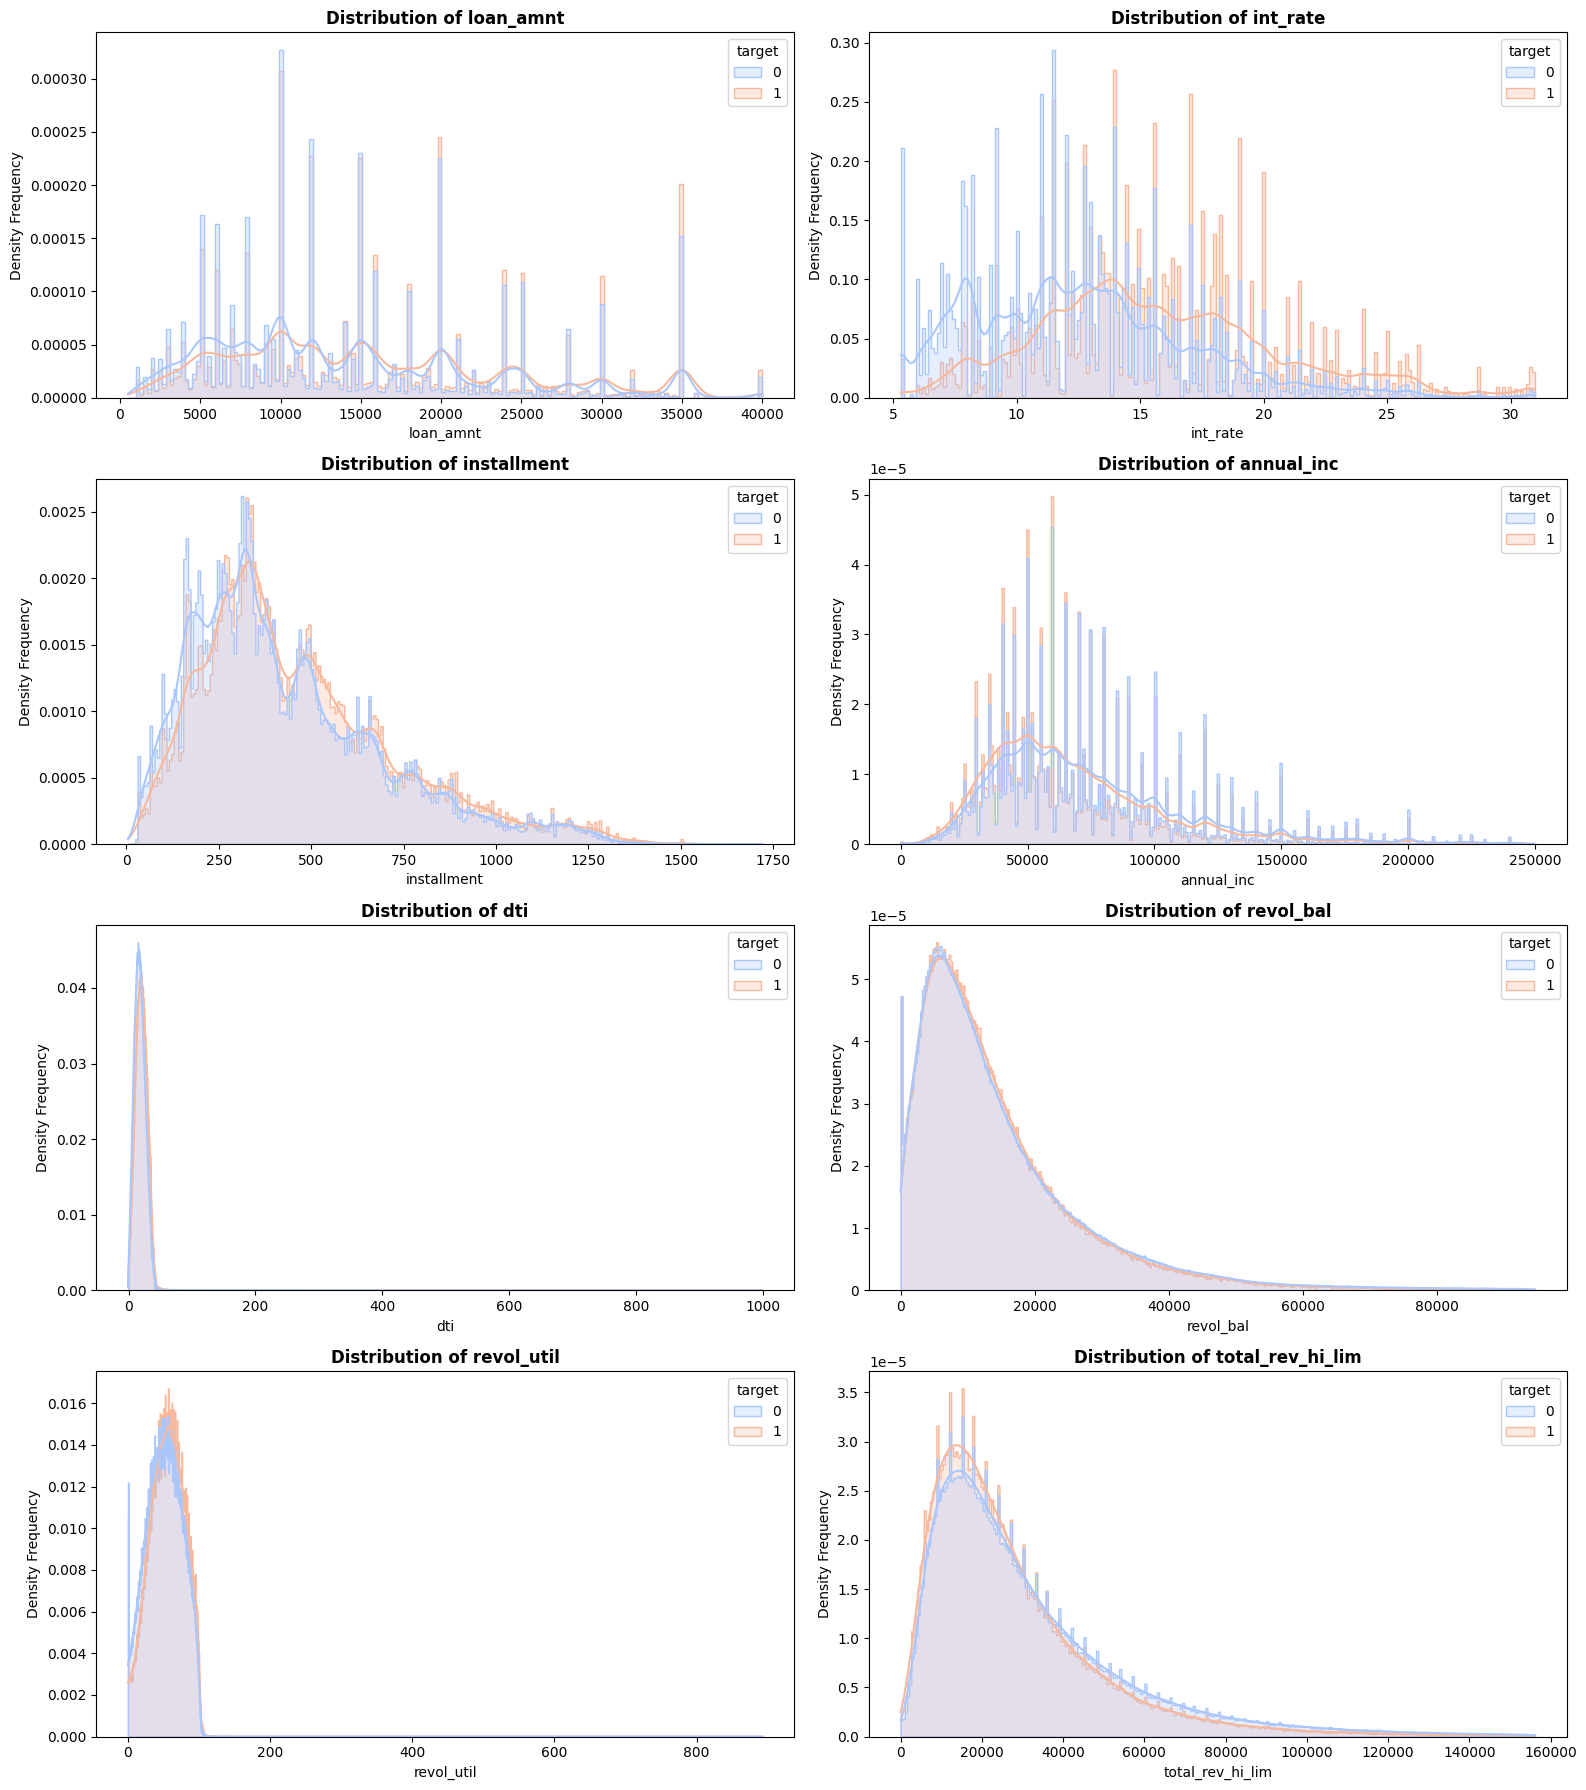


--- Continuous Feature Skewness (Goal: values close to 0) ---
loan_amnt            0.78
int_rate             0.71
installment          1.00
annual_inc          48.43
dti                 26.79
revol_bal           14.56
revol_util          -0.03
total_rev_hi_lim    61.22
dtype: float64


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# The top 8 most critical continuous metrics for lending risk
top_cont = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'revol_bal', 'revol_util', 'total_rev_hi_lim','policy_code']
valid_cont = [c for c in top_cont if c in continuous_cols]

# Create a clean grid of 4 rows and 2 columns
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, col in enumerate(valid_cont):
    # Temp dataframe for plotting
    plot_data = X_train[[col]].copy()
    plot_data['target'] = y_train
    
    # Cap highly skewed financial variables at the 99th percentile so the graphs don't stretch
    if col in ['annual_inc', 'revol_bal', 'total_rev_hi_lim']:
        upper_cap = plot_data[col].quantile(0.99)
        plot_data = plot_data[plot_data[col] < upper_cap]
        
    # Plot both Histogram and Density curve at once
    sns.histplot(
        data=plot_data, x=col, hue='target', 
        kde=True,                  # Adds the smooth density line
        element='step',            # Keeps bars looking crisp
        stat='density',            # Standardizes scale for matching curve
        common_norm=False,         # Scales curves independently per class
        palette='coolwarm', alpha=0.3, ax=axes[idx]
    )
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Density Frequency')

plt.tight_layout()
plt.show()

# Print simple skewness tracking values
print("\n--- Continuous Feature Skewness (Goal: values close to 0) ---")
print(X_train[valid_cont].skew().round(2))


#### DISCRETE VARS

In [20]:
# 1. Check for discrete features with absolutely zero mathematical variance
discr_variances = X_train[discrete_cols].var()
zero_var_discr = discr_variances[discr_variances == 0].index.tolist()
zero_var_discr 


['policy_code']

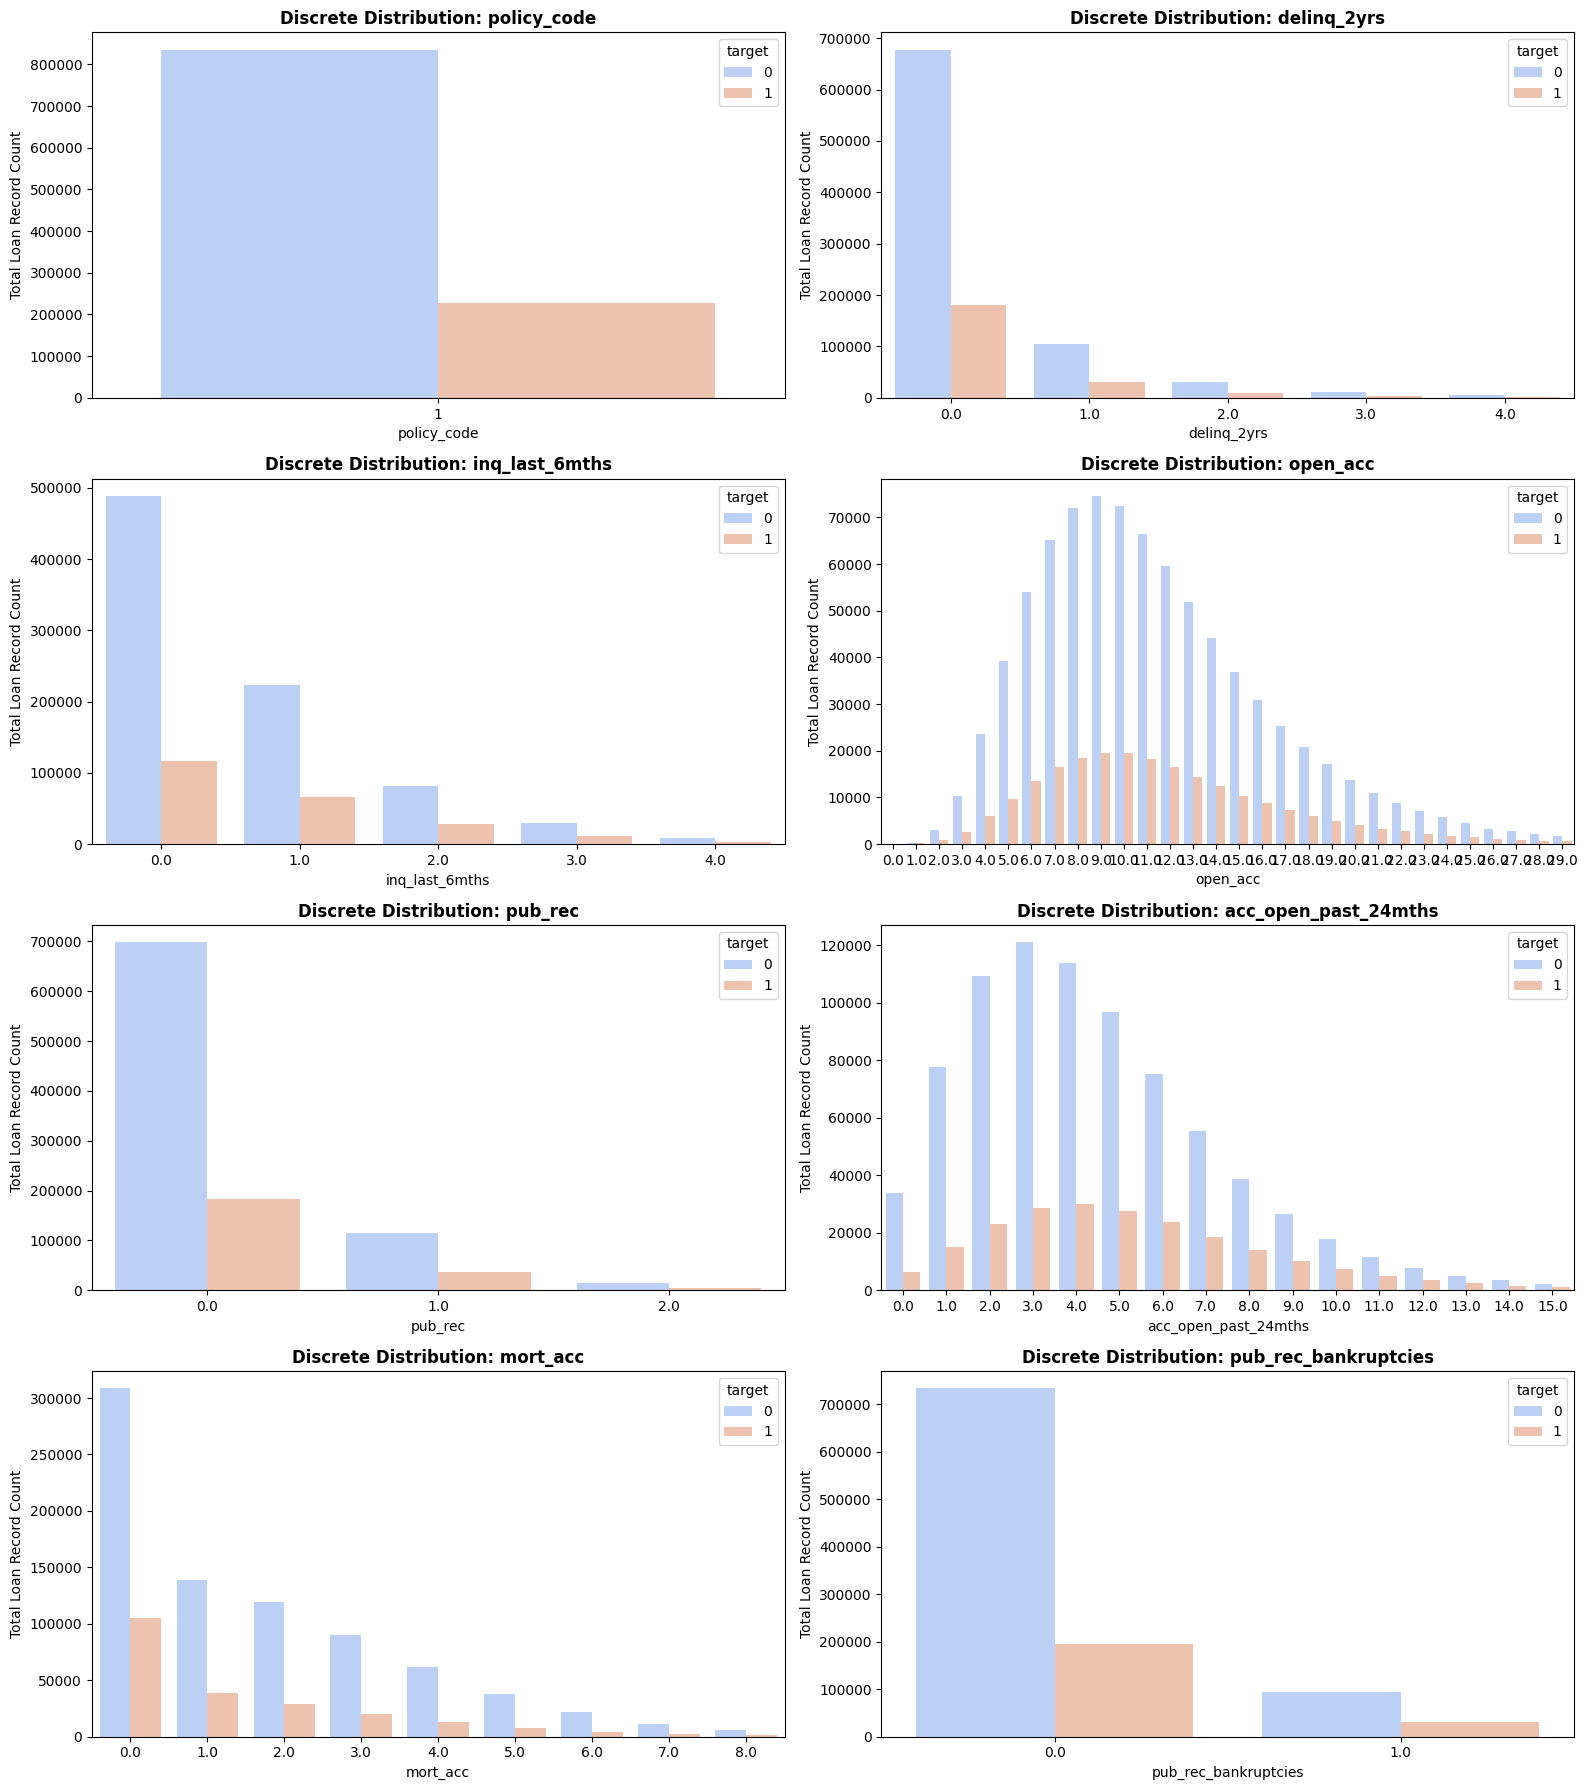

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Included policy_code directly into your target checklist
top_discr = [
    'policy_code',         # Visualizing this first as requested
    'delinq_2yrs', 
    'inq_last_6mths', 
    'open_acc', 
    'pub_rec', 
    'acc_open_past_24mths', 
    'mort_acc', 
    'pub_rec_bankruptcies'
]
valid_discr = [d for d in top_discr if d in discrete_cols]

# Create a clean 4x2 grid of plots
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, col in enumerate(valid_discr):
    plot_data = X_train[[col]].copy()
    plot_data['target'] = y_train
    
    # Cap extreme long-tail outliers at 99th percentile for visual clarity
    # (Skip policy_code since it has no variation)
    if col != 'policy_code':
        upper_cap = plot_data[col].quantile(0.99)
        plot_data = plot_data[plot_data[col] <= upper_cap]
    
    # Calculate explicit value counts split by target for a clean bar chart
    counts_df = plot_data.groupby([col, 'target']).size().reset_index(name='count')
    
    # Plot side-by-side grouped bars
    sns.barplot(
        data=counts_df, x=col, y='count', hue='target',
        palette='coolwarm', alpha=0.9, ax=axes[idx]
    )
    axes[idx].set_title(f'Discrete Distribution: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Total Loan Record Count')

plt.tight_layout()
plt.show()


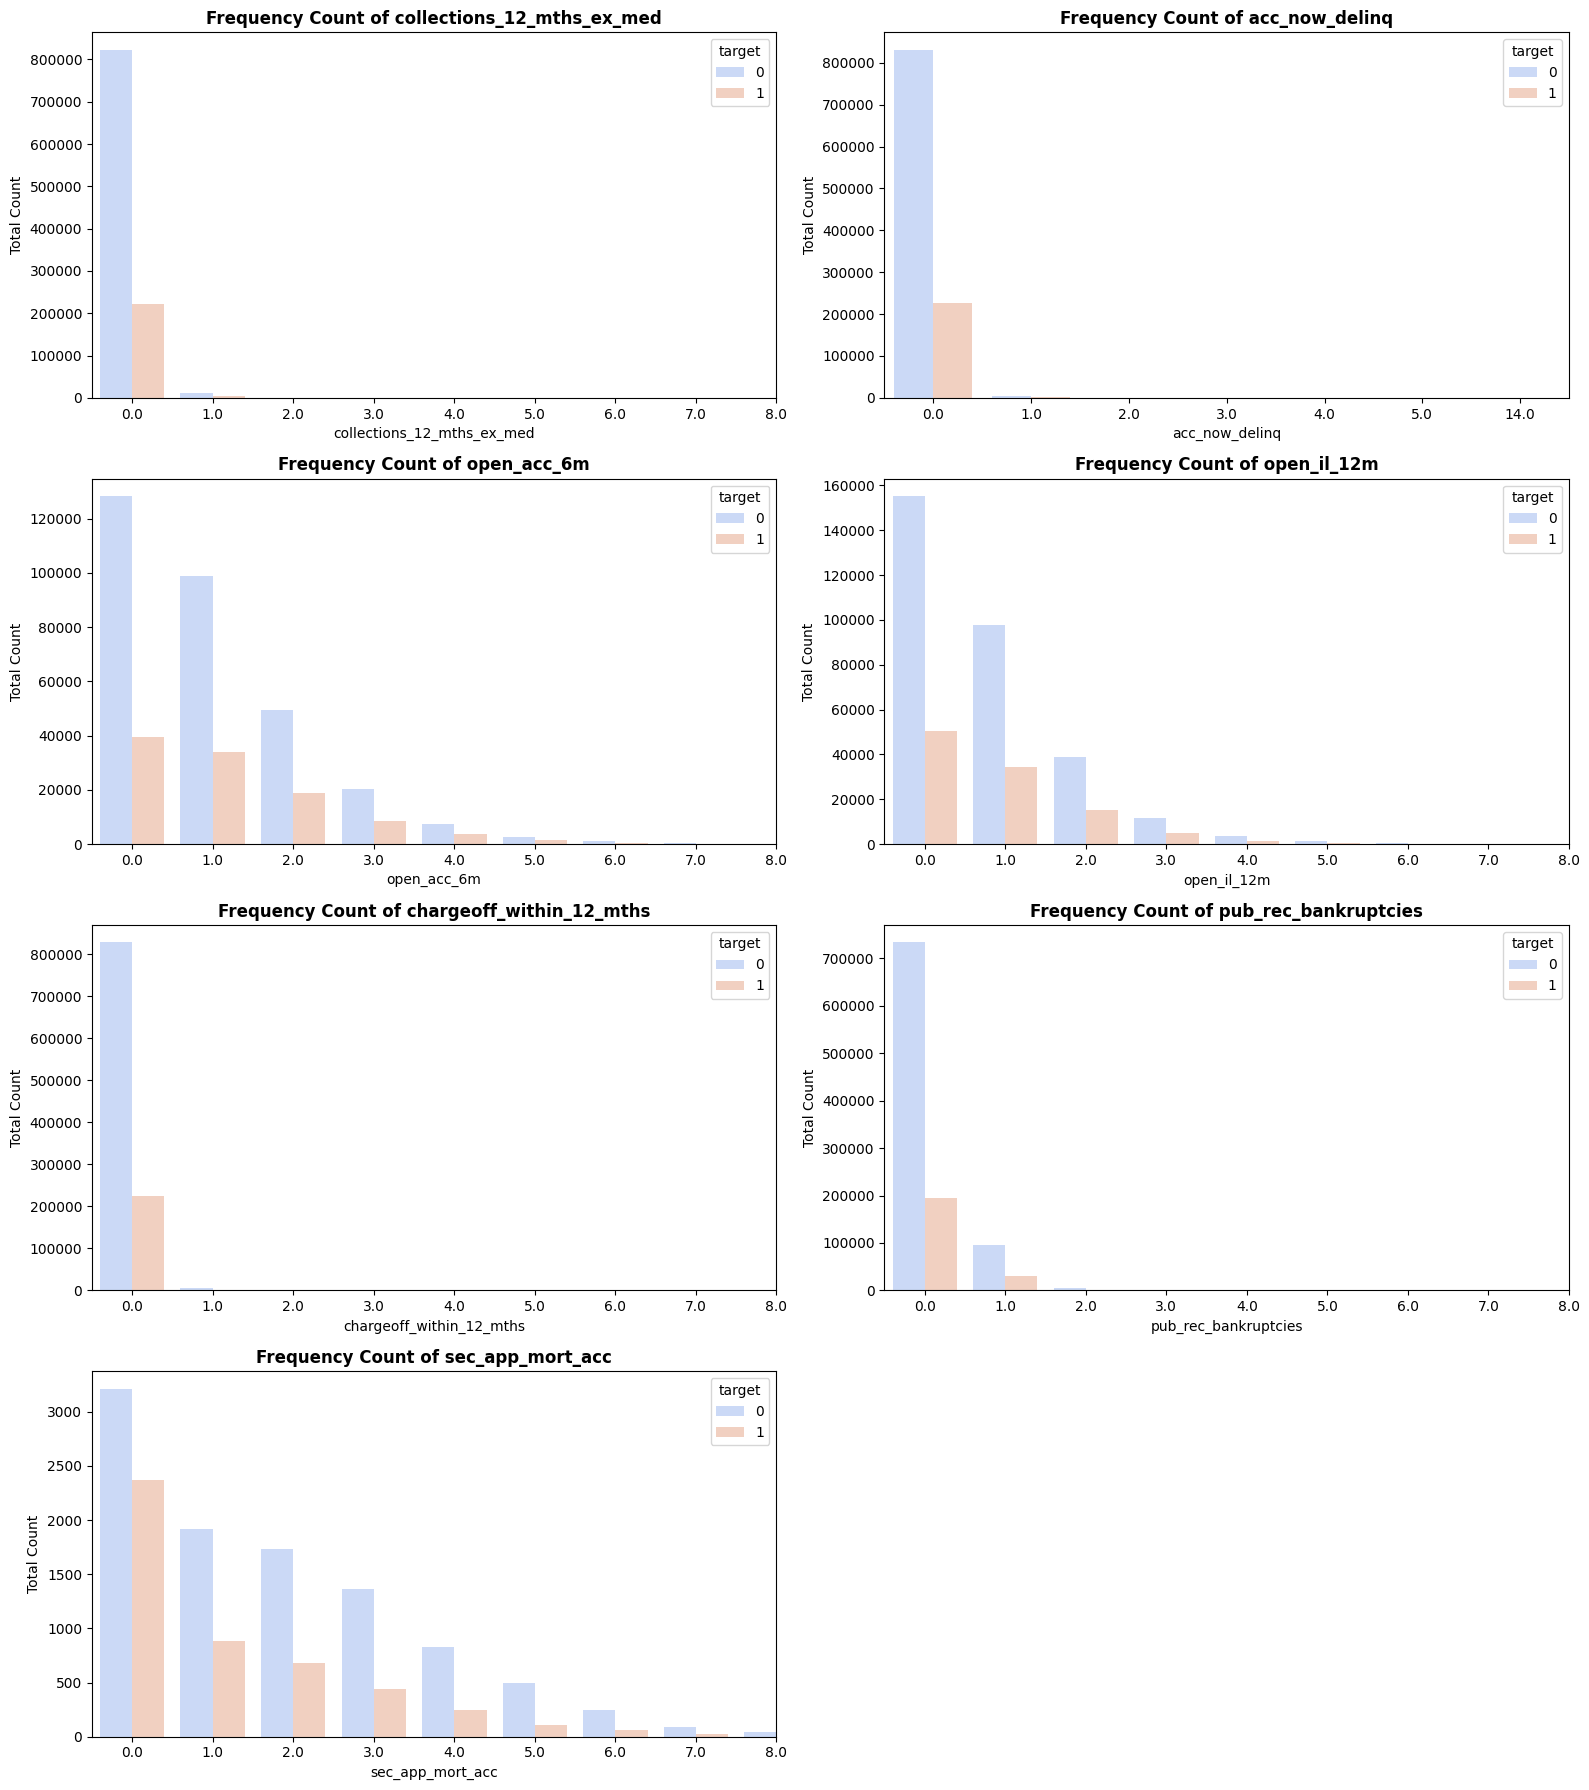

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pick the top 8 discrete metrics from your checklist
top_disc = [
    'collections_12_mths_ex_med', 'acc_now_delinq', 'open_acc_6m', 
    'open_il_12m', 'chargeoff_within_12_mths', 'pub_rec_bankruptcies', 
    'sec_app_mort_acc', 'hardship_length'
]
valid_disc = [c for c in top_disc if c in X_train.columns]

# Create a clean grid of 4 rows and 2 columns (8 slots total)
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, col in enumerate(valid_disc):
    # Temp dataframe for plotting to prevent mutating X_train
    plot_data = X_train[[col]].copy()
    plot_data['target'] = y_train
    plot_data = plot_data.dropna(subset=[col])
    
    # Use countplot instead of histplot for clean, discrete integer bars
    sns.countplot(
        data=plot_data, x=col, hue='target',
        palette='coolwarm', alpha=0.7, ax=axes[idx]
    )
    
    axes[idx].set_title(f'Frequency Count of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Total Count')
    
    # Compress the X-axis view if a rare high value stretches the grid too wide
    if plot_data[col].nunique() > 10:
        axes[idx].set_xlim(-0.5, 8)

# Programmatically hide any unused subplots so the canvas stays clean
for blank_idx in range(len(valid_disc), len(axes)):
    fig.delaxes(axes[blank_idx])

plt.tight_layout()
plt.show()


Dropped Policy_Code

In [22]:
# Permanent elimination of the zero-variance column verified by your plot
X_train = X_train.drop(columns=['policy_code'], errors='ignore')
X_test = X_test.drop(columns=['policy_code'], errors='ignore')

# Remove it from our tracking list as well
if 'policy_code' in discrete_cols:
    discrete_cols.remove('policy_code')

print(f"policy_code dropped! Current X_train columns: {X_train.shape[1]}")


policy_code dropped! Current X_train columns: 97


#### Outliers Detection for Continuous Var

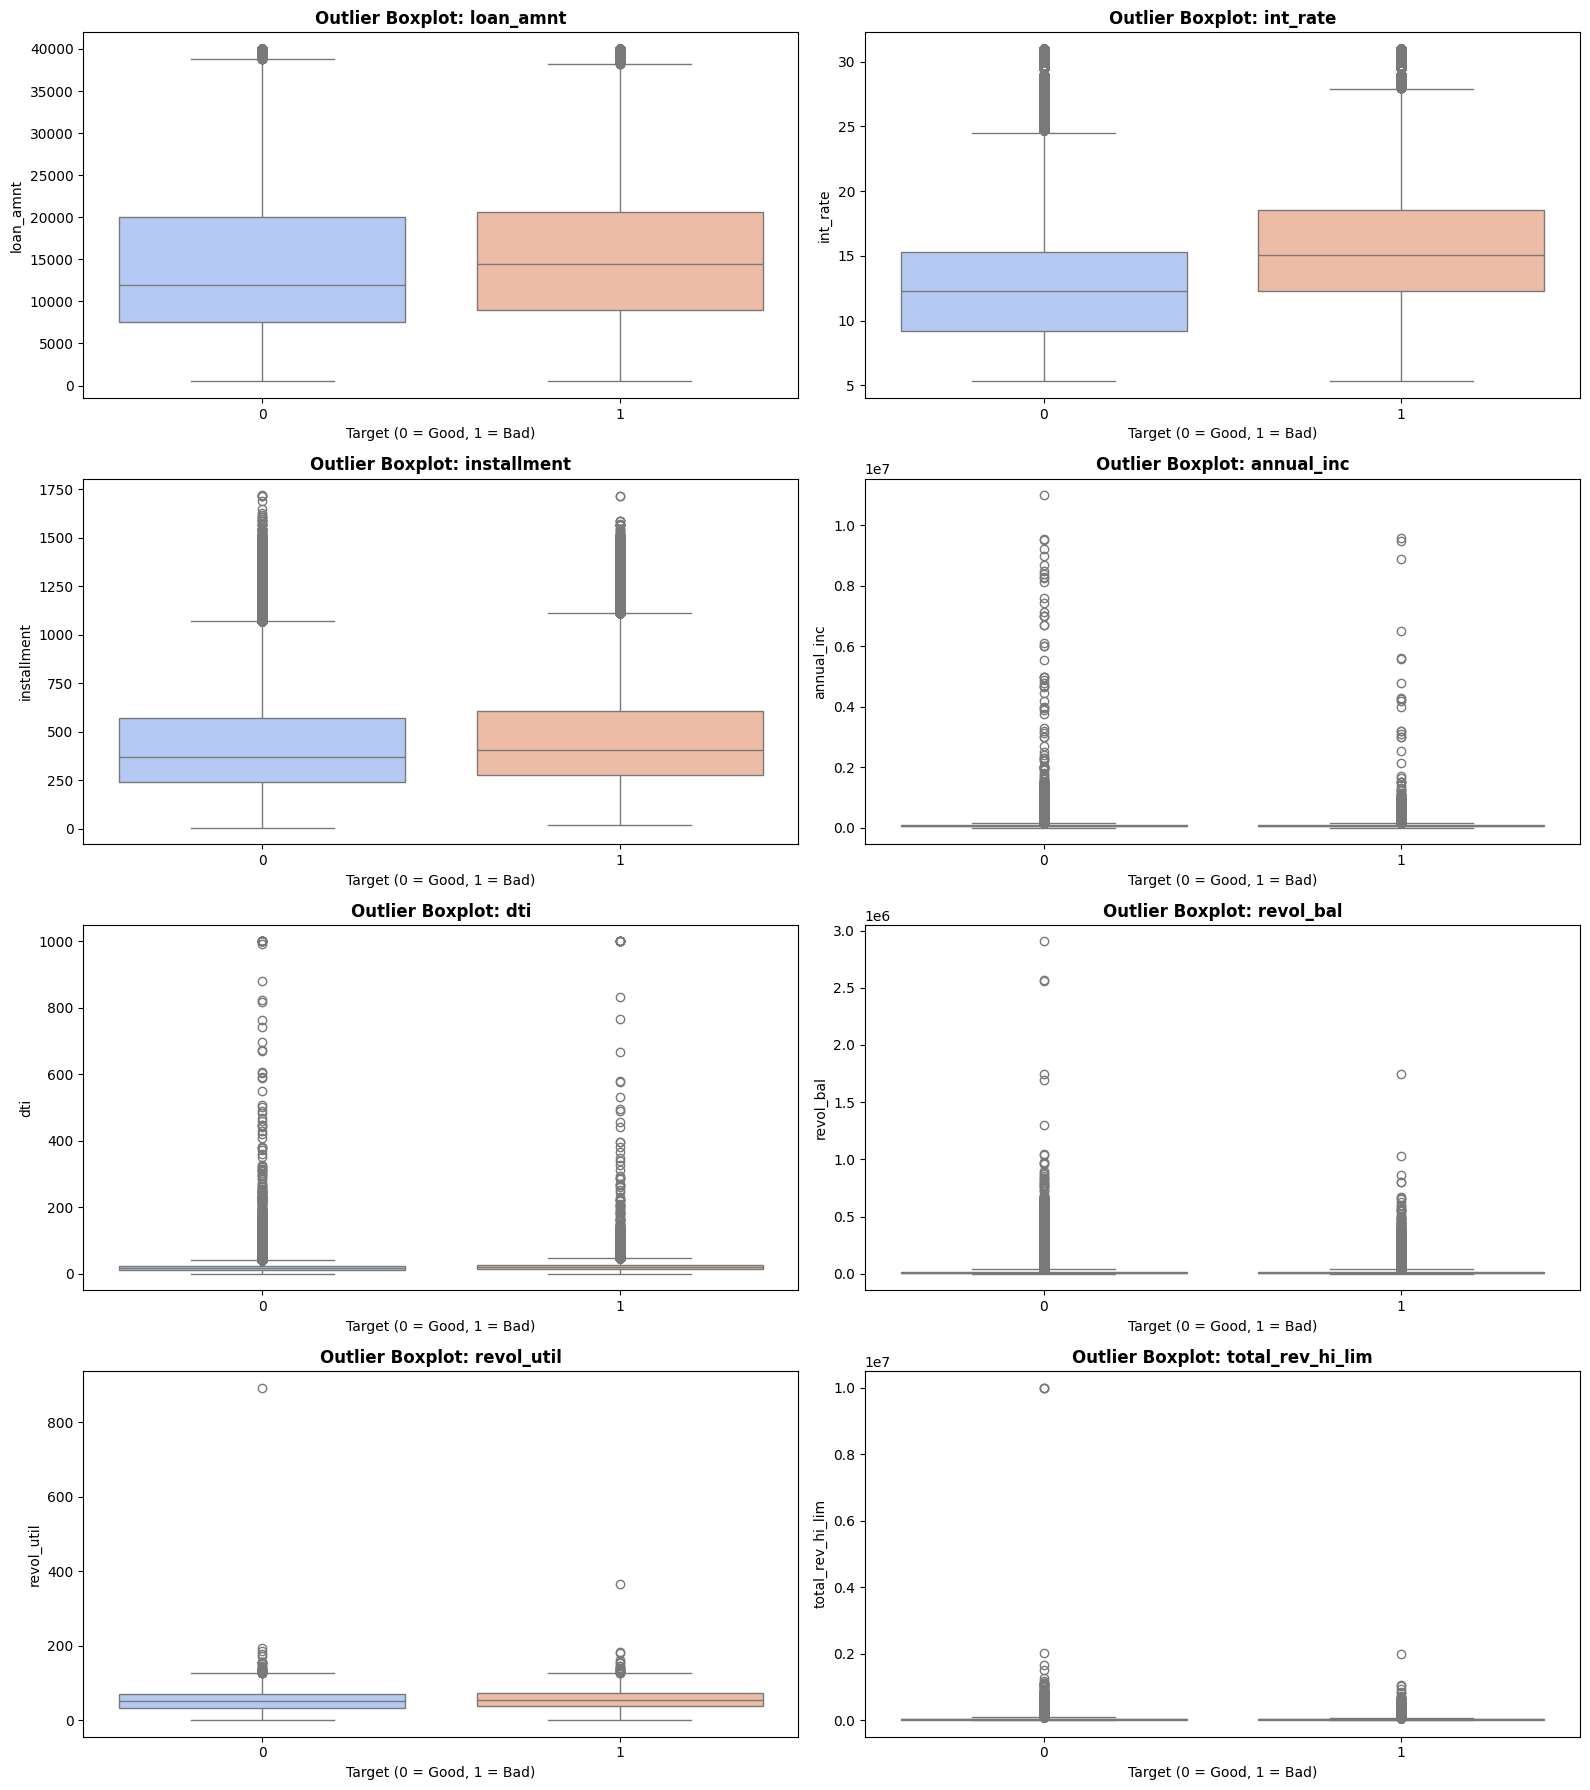

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# The top 8 continuous features we are analyzing
top_cont = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'revol_bal', 'revol_util', 'total_rev_hi_lim']
valid_cont = [c for c in top_cont if c in continuous_cols]

# Create a 4x2 grid of boxplots
fig, axes = plt.subplots(4, 2, figsize=(16, 18))
axes = axes.flatten()

for idx, col in enumerate(valid_cont):
    # Temporarily combine the single feature with y_train for plotting
    plot_data = X_train[[col]].copy()
    plot_data['target'] = y_train
    
    sns.boxplot(
        data=plot_data, x='target', y=col, hue='target',
        palette='coolwarm', legend=False, ax=axes[idx]
    )
    axes[idx].set_title(f'Outlier Boxplot: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Target (0 = Good, 1 = Bad)')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()


#### CATEROGICAL VARIABLES

In [24]:
# 1. Automatically find all categorical/text columns left in X_train
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Total Categorical Columns found: {len(cat_cols)}")

Total Categorical Columns found: 14


C:\Users\Hi\AppData\Local\Temp\ipykernel_14904\2304161092.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


In [25]:
print(cat_cols)

['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'earliest_cr_line', 'initial_list_status', 'application_type', 'verification_status_joint', 'sec_app_earliest_cr_line', 'disbursement_method']


Plotting risk distribution for exactly 11 categorical features.


C:\Users\Hi\AppData\Local\Temp\ipykernel_14904\3284110903.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Hi\AppData\Local\Temp\ipykernel_14904\3284110903.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Hi\AppData\Local\Temp\ipykernel_14904\3284110903.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Hi\AppData\Local\Temp\ipykernel_14904\3284110903.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set 

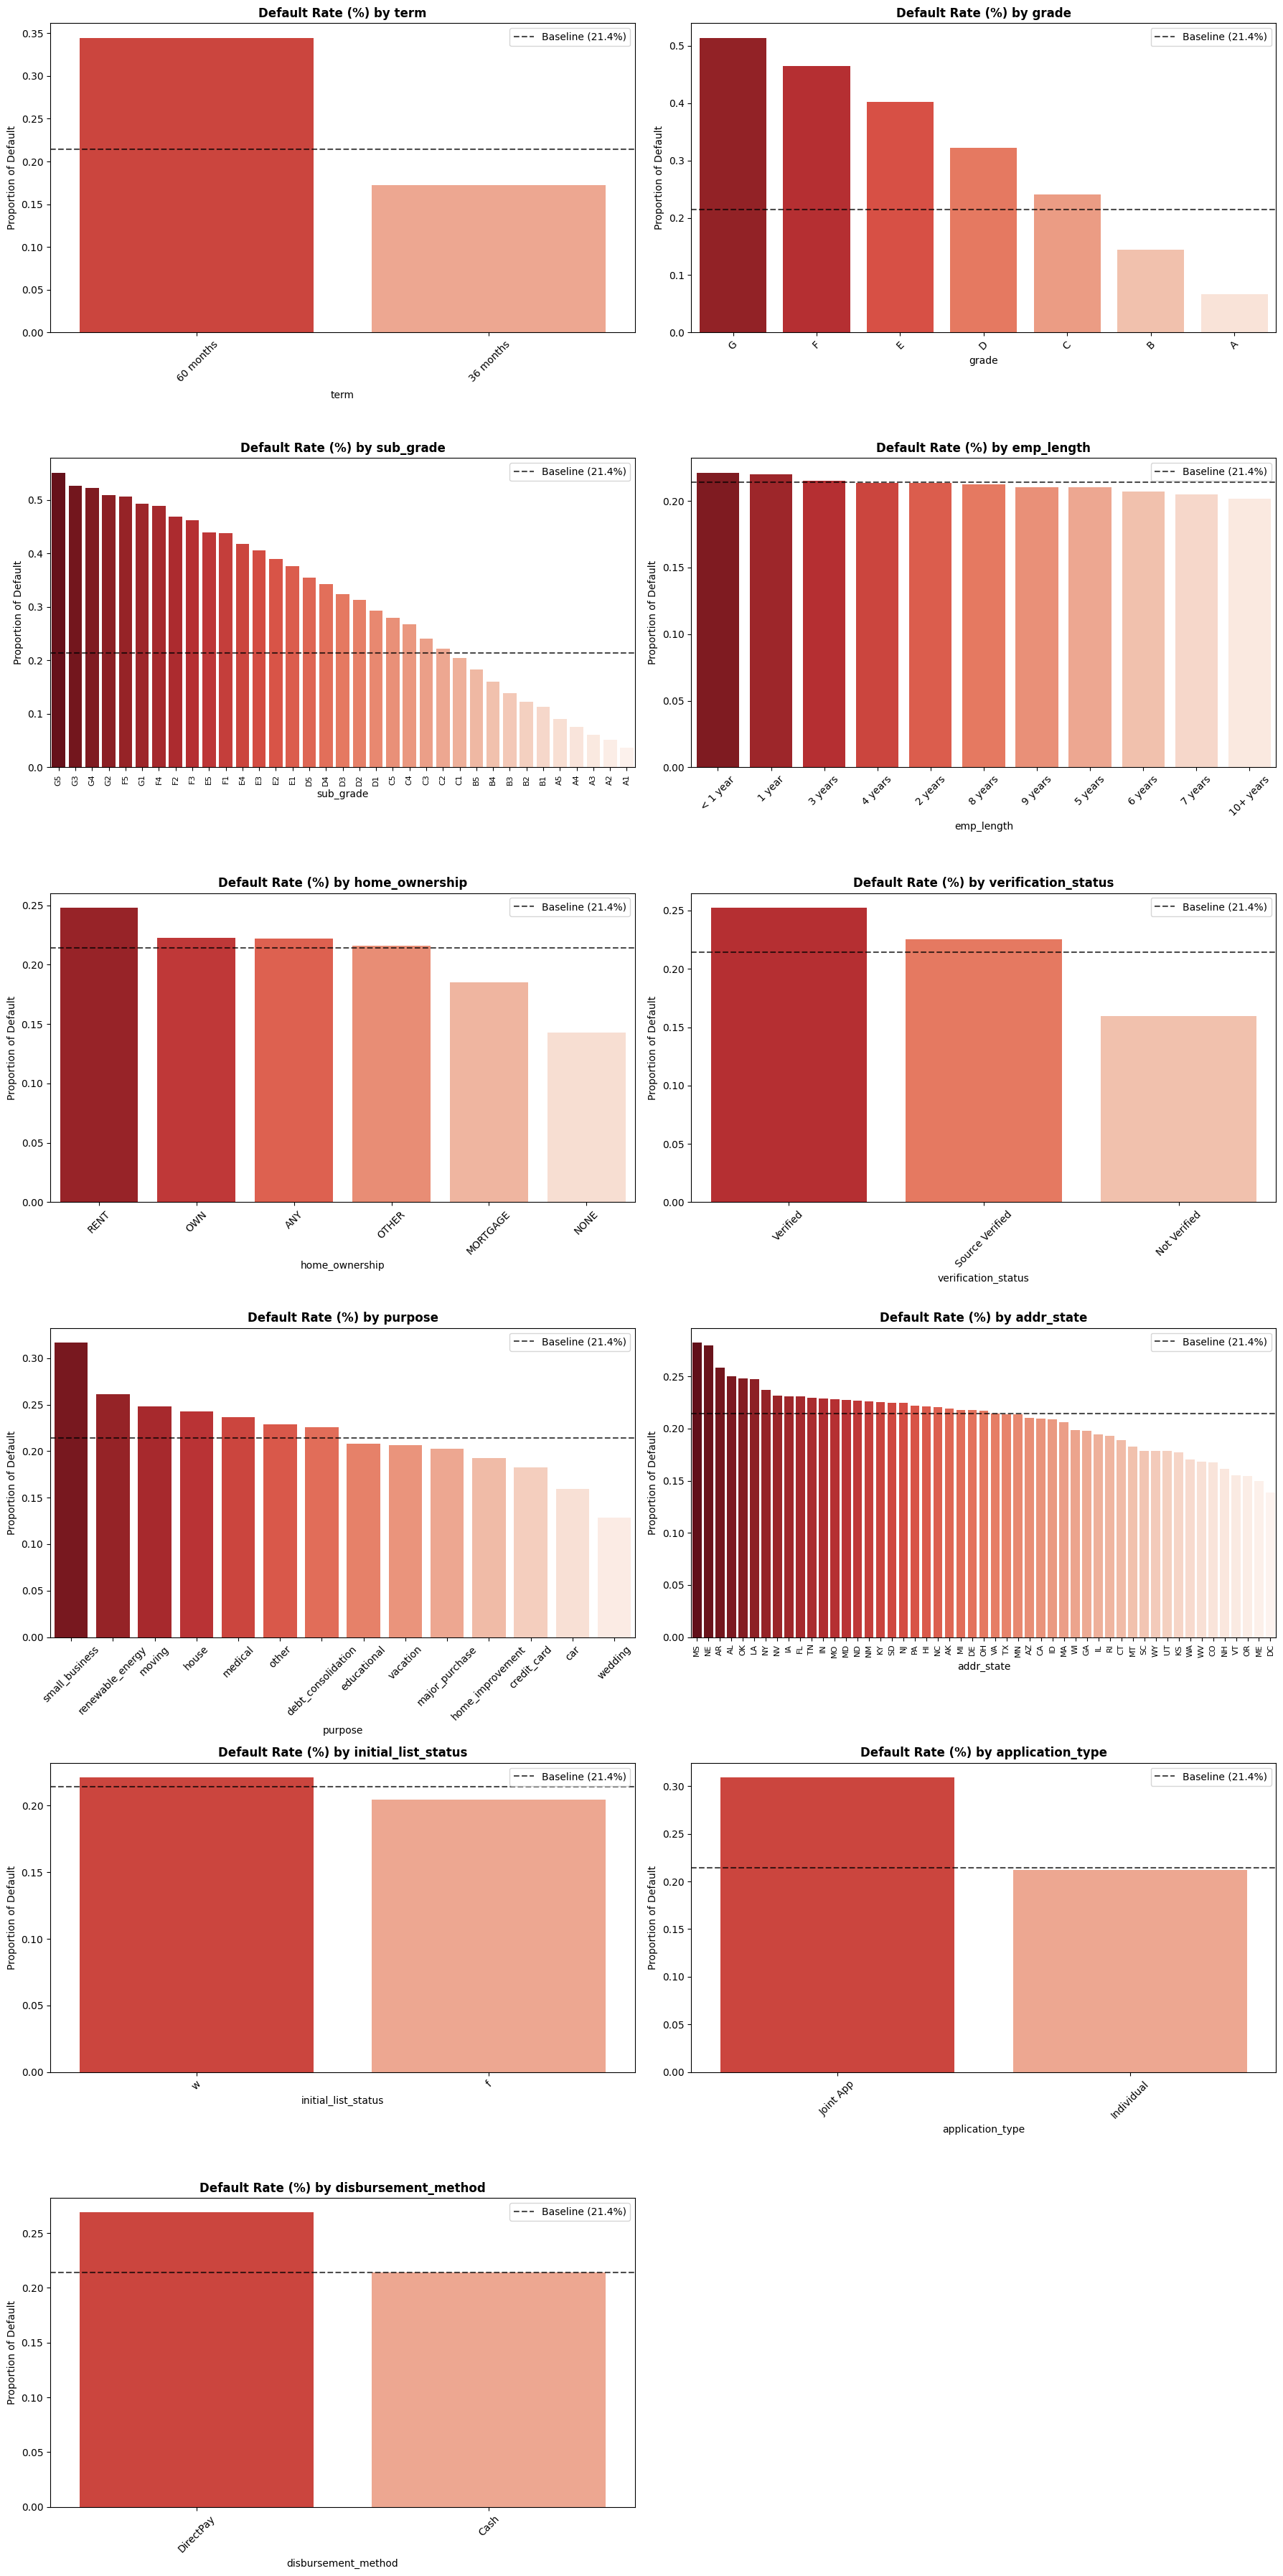

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define your 11 target columns plus 1 extra to make a total of 12 (6x2 grid)
target_cats = [
    'term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 
    'verification_status', 'purpose', 'addr_state', 'initial_list_status', 
    'application_type', 'disbursement_method'
]

# Identify available columns in your current workspace
available_cols = [col for col in target_cats if col in X_train.columns]


print(f"Plotting risk distribution for exactly {len(available_cols)} categorical features.")

# Calculate the baseline default rate for the whole training set (~21.4%)
baseline_risk = y_train.mean()

# Set up a fixed 6x2 grid layout (12 slots)
fig, axes = plt.subplots(6, 2, figsize=(18, 36))
axes = axes.flatten()

for idx, col in enumerate(available_cols):
    # Reference your active 'X_train_base' dataframe
    plot_data = X_train[[col]].copy()
    plot_data['target'] = y_train
    
    # Calculate the default rate per category (mean of 0s and 1s)
    cat_risk = plot_data.groupby(col)['target'].mean().reset_index()
    cat_risk = cat_risk.sort_values(by='target', ascending=False)
    
    # Plotting the risk bars
    sns.barplot(
        data=cat_risk, x=col, y='target', 
        palette='Reds_r', ax=axes[idx]
    )
    
    # Add a horizontal line representing the overall baseline default rate (~21%)
    axes[idx].axhline(baseline_risk, color='black', linestyle='--', alpha=0.7, label=f'Baseline ({baseline_risk*100:.1f}%)')
    
    axes[idx].set_title(f'Default Rate (%) by {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Proportion of Default')
    axes[idx].set_xlabel(col)
    
    # Set custom tick layout spacing depending on the feature's cardinality
    if col in ['sub_grade', 'addr_state']:
        axes[idx].tick_params(axis='x', rotation=90, labelsize=8)
    else:
        axes[idx].tick_params(axis='x', rotation=45)
        
    axes[idx].legend()

# Cleanly drop any unused subplot axes spaces from the canvas grid layout if count < 12
for blank_idx in range(len(available_cols), len(axes)):
    fig.delaxes(axes[blank_idx])

plt.tight_layout()
plt.show()


In [29]:
print(cat_risk)

  disbursement_method    target
1           DirectPay  0.268824
0                Cash  0.213809


In [35]:
X_train.home_ownership.value_counts()

home_ownership
MORTGAGE    525079
RENT        423132
OWN         113993
ANY            221
OTHER          153
NONE            49
Name: count, dtype: int64

In [37]:
X_train.purpose.value_counts()

purpose
debt_consolidation    616934
credit_card           232247
home_improvement       68739
other                  61648
major_purchase         23181
small_business         12440
medical                12437
car                    11589
moving                  7579
vacation                7105
house                   5799
wedding                 1856
renewable_energy         736
educational              337
Name: count, dtype: int64

## HANDLING MISSING VALUES

In [30]:
# 1. Calculate missing percentages across all remaining features in X_train
missing_pct = (X_train.isnull().sum() / len(X_train)) * 100

# 2. Filter out columns that have 0% missing values to isolate the issues
missing_summary = missing_pct[missing_pct > 0].sort_values(ascending=False)

print(f"--- Missing Data Audit ({len(missing_summary)} features contain NaNs) ---")
print(missing_summary.head(40)) # Look at the top 40 worst columns


--- Missing Data Audit (83 features contain NaNs) ---
sec_app_mths_since_last_major_derog    99.490602
sec_app_revol_util                     98.631317
revol_bal_joint                        98.606190
sec_app_earliest_cr_line               98.606096
sec_app_inq_last_6mths                 98.606096
sec_app_open_acc                       98.606096
sec_app_open_act_il                    98.606096
sec_app_mort_acc                       98.606096
sec_app_num_rev_accts                  98.606096
sec_app_chargeoff_within_12_mths       98.606096
sec_app_collections_12_mths_ex_med     98.606096
verification_status_joint              98.091240
dti_joint                              98.077689
annual_inc_joint                       98.077500
mths_since_last_record                 82.925900
mths_since_recent_bc_dlq               76.294034
mths_since_last_major_derog            73.709590
mths_since_recent_revol_delinq         66.593640
il_util                                66.124990
mths_since_rcnt

Before applying any technical feature deletion or imputation, we audited the missing data structure of our 98 features. Missingness in credit risk modeling is rarely random noise; it represents heavy operational and behavioral signals that require distinct handling strategies based on statistical theory.

### Part 1: The Three Statistical Mechanisms of Missing Data

Statistical theory classifies missing data into three classical buckets based on the underlying reason for the absence of values:

1. Missing Completely at Random (MCAR)
* Definition: The missingness is entirely independent of any observed data or unobserved traits. It is pure, random noise such as system glitches or lost physical forms.
* Imputation Strategy: Safe to drop or impute using global statistical aggregates like mean, median, or mode without introducing structural bias.

2. Missing at Random (MAR)
* Definition: The missingness appears non-random on its own but can be completely explained and predicted by another observed variable already present in the dataset.
* Our Empirical Proof: Cross-tabulating application_type against annual_inc_joint shows that joint columns are missing 100% of the time when the loan is an "Individual" application. The missingness is a systematic structural design, not a random anomaly.
* Imputation Strategy: Global imputation fails. These must be handled conditionally. For example, if the application is Individual, fill missing joint assets with 0.

3. Missing Not at Random (MNAR)
* Definition: The probability of data being missing is directly related to the unobserved value itself, or the event simply never occurred. The absence of data is a heavy behavioral signal.
* Lending Domain Case: Historical derogatory features like mths_since_last_delinq are missing because the borrower has a perfect payment history and has never defaulted. 
* Imputation Strategy: Filling with a median completely destroys the risk signal and penalizes good customers. We will use a high sentinel flag like 999 months for the linear Base Model, while allowing XGBoost to partition the NaN states natively as a low-risk separator.

---

### Part 2: Operational Domain Group Filtering Action Plan

Based on the mapping of our 83 columns containing missing values, we have categorized them into three domain-driven groups to finalize our data cleaning matrix:

Group 1: Joint and Secondary Application Features (98% to 99% Missing)
* Features Included: sec_app_ columns and _joint fields.
* Mechanism Type: MAR (Missing at Random) — Explained entirely by individual application types.
* Action: Drop Completely. Since individual borrowers represent over 98% of our dataset, maintaining these sparse columns adds severe memory overhead to our 12GB RAM without contributing any dense pattern depth.

Group 2: No Derogatory History Features (50% to 83% Missing)
* Features Included: mths_since_last_record, mths_since_recent_bc_dlq, mths_since_last_major_derog, mths_since_last_delinq.
* Mechanism Type: MNAR (Missing Not at Random) — Missingness implies high-quality borrower status.
* Action: Retain and Keep Intact. These represent crucial risk-differentiation boundaries that our XGBoost Detective Framework will aggressively leverage to discover the blind spots of the base model.

Group 3: Historical Time-Blocked Bureau Metrics (60% to 66% Missing)
* Features Included: il_util, mths_since_rcnt_il, all_util, inq_fi, open_rv_12m, max_bal_bc, total_bal_il, etc.
* Mechanism Type: Structural Missingness — These features did not exist in the bureau reporting infrastructure during the early years of LendingClub origination, creating massive artificial blocks of NaN rows.
* Action: Drop Completely. Because the missing values are bound to historical timeline windows rather than organic borrower financial profiles, keeping them creates fractured, sparse clusters that degrade generalization performance.


In [31]:
# 1. Explicitly isolate the features to drop based on our risk rules
high_missing_drops = [
    # Group 1: Joint Applications (98%+ empty)
    'sec_app_mths_since_last_major_derog', 'sec_app_revol_util', 'revol_bal_joint',
    'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_open_acc',
    'sec_app_open_act_il', 'sec_app_mort_acc', 'sec_app_num_rev_accts',
    'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med',
    'verification_status_joint', 'dti_joint', 'annual_inc_joint',
    
    # Group 3: Time-blocked modern metrics (60%+ empty across early years)
    'il_util', 'mths_since_rcnt_il', 'all_util', 'inq_fi', 'open_rv_12m',
    'inq_last_12m', 'open_il_12m', 'open_rv_24m', 'max_bal_bc', 'total_bal_il',
    'total_cu_tl', 'open_act_il', 'open_acc_6m', 'open_il_24m'
]

# 2. Execute the drop on both training and testing datasets
X_train = X_train.drop(columns=high_missing_drops, errors='ignore')
X_test = X_test.drop(columns=high_missing_drops, errors='ignore')

# 3. Dynamically update our continuous and discrete tracking lists
continuous_cols = [c for c in continuous_cols if c in X_train.columns]
discrete_cols = [d for d in discrete_cols if d in X_train.columns]

In [32]:
print("--- Missing Value Filter Complete ---")
print(f"X_train current shape: {X_train.shape[0]:,} rows × {X_train.shape[1]} columns")

--- Missing Value Filter Complete ---
X_train current shape: 1,062,627 rows × 69 columns


#### FEATURE SELECTION

In [33]:
# 1. DYNAMICALLY REBUILD: Pull only the numeric columns actually present in X_train right now
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

 We run Raw Pairwise Spearman Correlation Filter: Run the rank-based Spearman loop on un-imputed data to identify and drop mathematical twins (like installment vs loan_amnt) without warping the data shape.

In [34]:
import numpy as np
import pandas as pd

# 1. Run Spearman correlation on RAW data
raw_spearman_corr = X_train[numeric_cols].corr(method='spearman').abs()

# 2. Handle non-overlapping row or zero-variance traps
raw_spearman_corr = raw_spearman_corr.fillna(0)

# 3. Select upper triangle to scan for twins
upper_tri = raw_spearman_corr.where(np.triu(np.ones(raw_spearman_corr.shape), k=1).astype(bool))

# 4. Identify features with a rank correlation greater than 0.85
to_drop_spearman = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]

print(f"Features dropped via Raw Pairwise Spearman filter: {to_drop_spearman}")




Features dropped via Raw Pairwise Spearman filter: ['installment', 'avg_cur_bal', 'mths_since_recent_revol_delinq', 'num_rev_tl_bal_gt_0', 'num_sats', 'percent_bc_gt_75', 'tot_hi_cred_lim', 'total_bc_limit', 'total_il_high_credit_limit']


In [38]:
# Safely remove the confirmed twins from your active workspaces
X_train = X_train.drop(columns=to_drop_spearman, errors='ignore')
X_test = X_test.drop(columns=to_drop_spearman, errors='ignore')

# Instantly update tracking lists so upcoming loops don't look for deleted columns
continuous_cols = [c for c in continuous_cols if c in X_train.columns]
discrete_cols = [d for d in discrete_cols if d in X_train.columns]
numeric_cols = [n for n in numeric_cols if n in X_train.columns]

print("--- Multi-Collinearity Cleanup Complete ---")
print(f"Final training workspace dimensions: {X_train.shape}")


--- Multi-Collinearity Cleanup Complete ---
Final training workspace dimensions: (1062627, 60)


In [39]:
print(list(X_train.columns))


['loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr

## The Dual-Track Pipeline 
Once we remove redundant columns, our dataset splits into two independent data prep tracks based on what each model physically requires.
Track A: The Baseline Workspace (For Logistic Regression)
Track B: The Detective Workspace (For XGBoost)

## Track A: The Baseline Workspace (For Logistic Regression)This track cleans and standardises data according to strict linear assumptions:

In [40]:
# 1. Create a dedicated workspace copy specifically for Track A (Baseline Model)
X_train_base = X_train.copy()
X_test_base = X_test.copy()

In [41]:
nan_proportions = X_train_base.isnull().mean()
print(nan_proportions[nan_proportions > 0].sort_values(ascending=False).round(4))


mths_since_last_record         0.8293
mths_since_recent_bc_dlq       0.7629
mths_since_last_major_derog    0.7371
mths_since_last_delinq         0.5040
mths_since_recent_inq          0.1312
num_tl_120dpd_2m               0.0900
mo_sin_old_il_acct             0.0811
emp_length                     0.0584
pct_tl_nvr_dlq                 0.0529
num_rev_accts                  0.0528
mo_sin_rcnt_rev_tl_op          0.0528
mo_sin_old_rev_tl_op           0.0528
num_bc_tl                      0.0528
num_actv_rev_tl                0.0528
mo_sin_rcnt_tl                 0.0528
num_tl_op_past_12m             0.0528
num_op_rev_tl                  0.0528
num_tl_90g_dpd_24m             0.0528
num_tl_30dpd                   0.0528
num_actv_bc_tl                 0.0528
tot_coll_amt                   0.0528
total_rev_hi_lim               0.0528
tot_cur_bal                    0.0528
num_accts_ever_120_pd          0.0528
num_il_tl                      0.0528
bc_util                        0.0485
bc_open_to_b

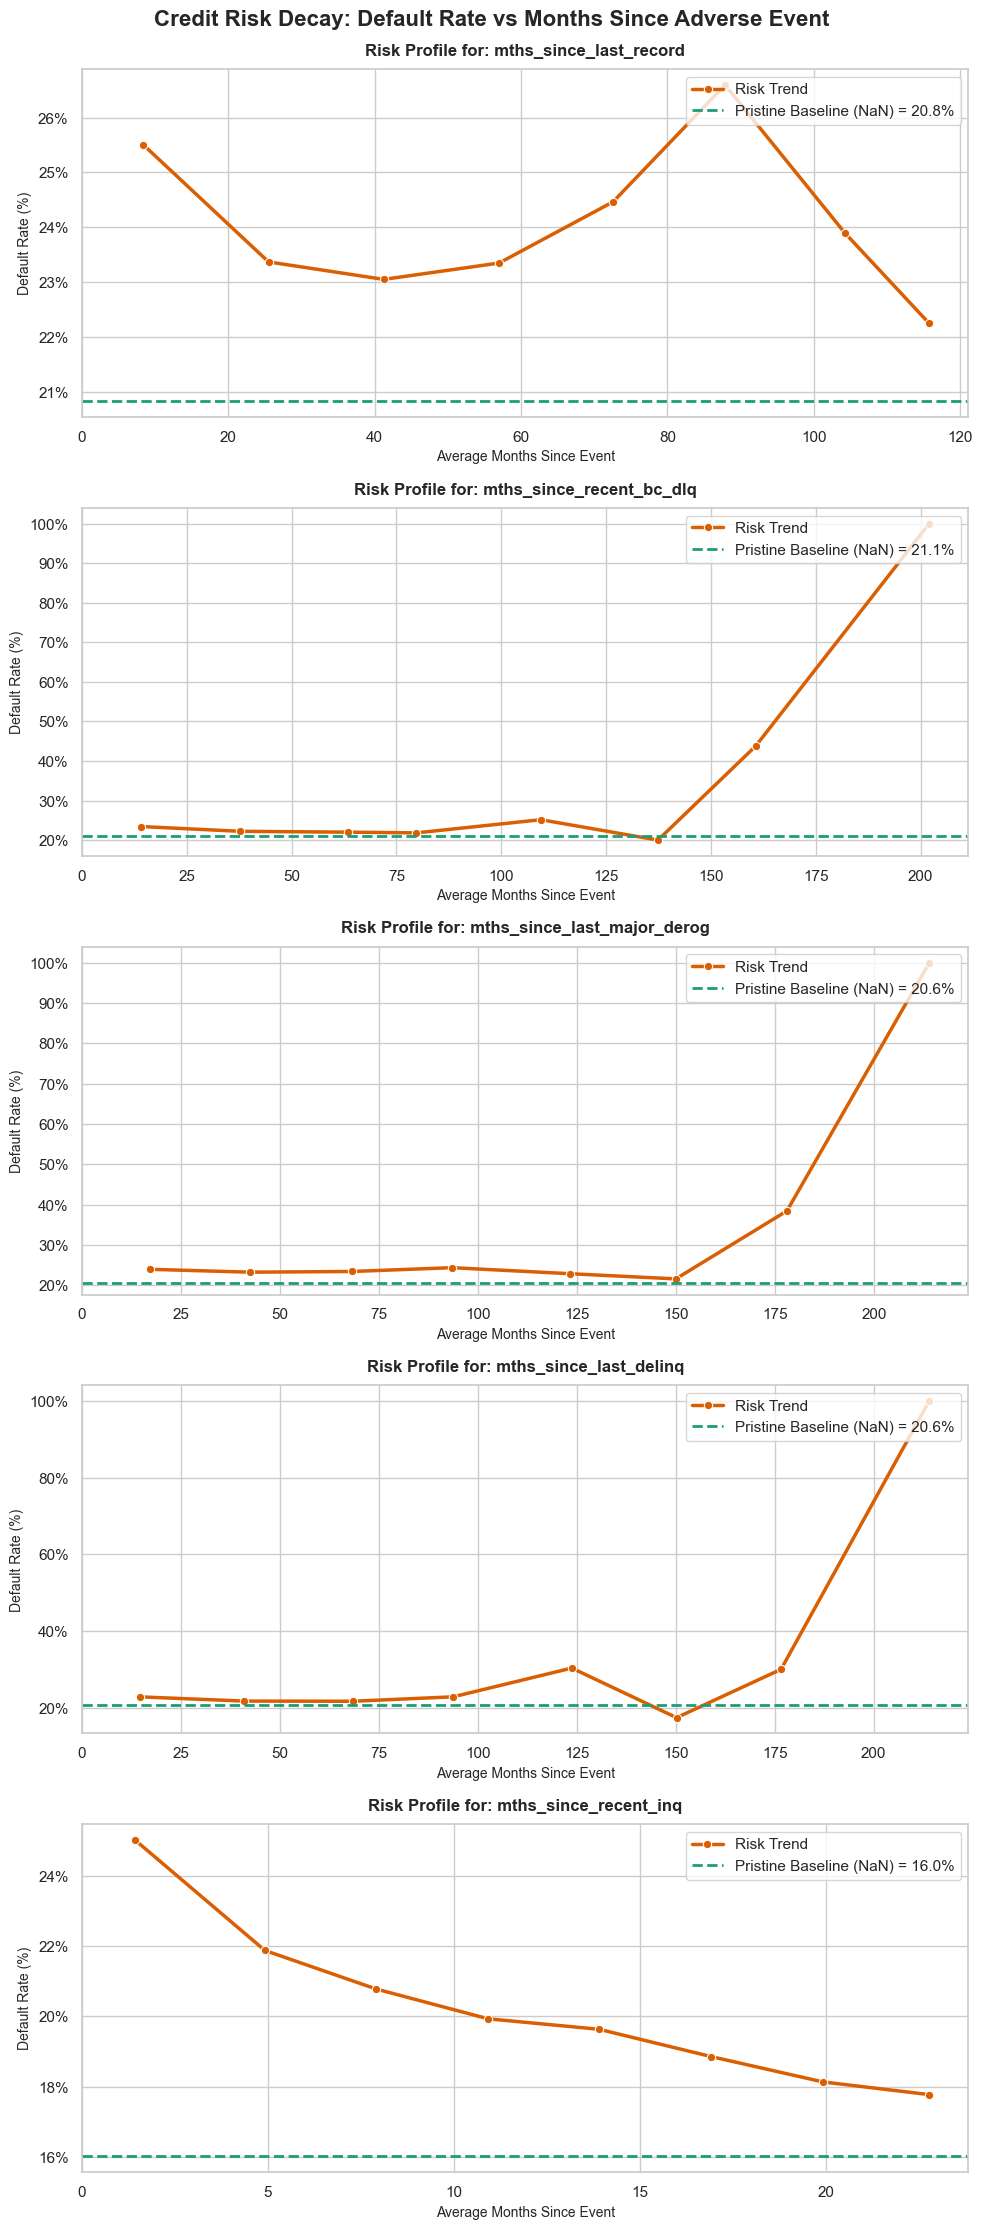

In [44]:
# import matplotlib.pyplot as plt
# import numpy as np
# import pandas as pd
# import seaborn as sns

# # 1. Temporarily join your raw X_train and y_train for the trend calculation
# plot_df = X_train.copy()
# plot_df['target'] = y_train
# target_col = 'target'

# Your exact active columns to check
sentinel_cols = [
    'mths_since_last_record',
    'mths_since_recent_bc_dlq',
    'mths_since_last_major_derog',
    'mths_since_last_delinq',
    'mths_since_recent_inq'
]

# Quick safety check to ensure columns exist in your current 60-feature workspace
valid_sentinel_cols = [c for c in sentinel_cols if c in plot_df.columns]

# Set up visual parameters
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(len(valid_sentinel_cols), 1, figsize=(10, 4.5 * len(valid_sentinel_cols)))
fig.suptitle("Credit Risk Decay: Default Rate vs Months Since Adverse Event", fontsize=16, fontweight='bold', y=0.99)

# Fix indexing edge-case if only 1 column is found valid
if len(valid_sentinel_cols) == 1:
    axes = [axes]

for i, col in enumerate(valid_sentinel_cols):
    ax = axes[i]
    
    # Isolate rows where the event actually occurred (ignore NaNs for the orange trend line)
    valid_data = plot_df[[col, target_col]].dropna()
    
    if len(valid_data) == 0:
        ax.text(0.5, 0.5, f"No populated data for {col}", ha='center', va='center')
        continue
        
    # Dynamic binning: Group the continuous months into 8 logical segments
    valid_data['bin'] = pd.cut(valid_data[col], bins=min(8, valid_data[col].nunique()), duplicates='drop')
    
    # Calculate the average month position and default percentage per segment
    bin_stats = valid_data.groupby('bin', observed=False).agg(
        mean_month=(col, 'mean'),
        default_rate=(target_col, 'mean')
    ).reset_index().dropna()
    
    # Plot the downward credit risk decay trend line (Orange)
    sns.lineplot(
        data=bin_stats, x='mean_month', y='default_rate', 
        ax=ax, marker='o', linewidth=2.5, color='#d95f02', label='Risk Trend'
    )
    
    # Isolate the missing records to compute the Pristine Baseline default rate (Green)
    nan_data = plot_df[plot_df[col].isna()]
    if len(nan_data) > 0:
        nan_default_rate = nan_data[target_col].mean()
        ax.axhline(
            y=nan_default_rate, color='#1b9e77', linestyle='--', linewidth=2,
            label=f'Pristine Baseline (NaN) = {nan_default_rate:.1%}'
        )
    
    # Formatting to keep it polished and readable
    ax.set_title(f"Risk Profile for: {col}", fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel("Default Rate (%)", fontsize=10)
    ax.set_xlabel("Average Months Since Event", fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    ax.legend(loc='upper right', frameon=True)
    ax.set_xlim(left=0)

plt.tight_layout()
plt.show()


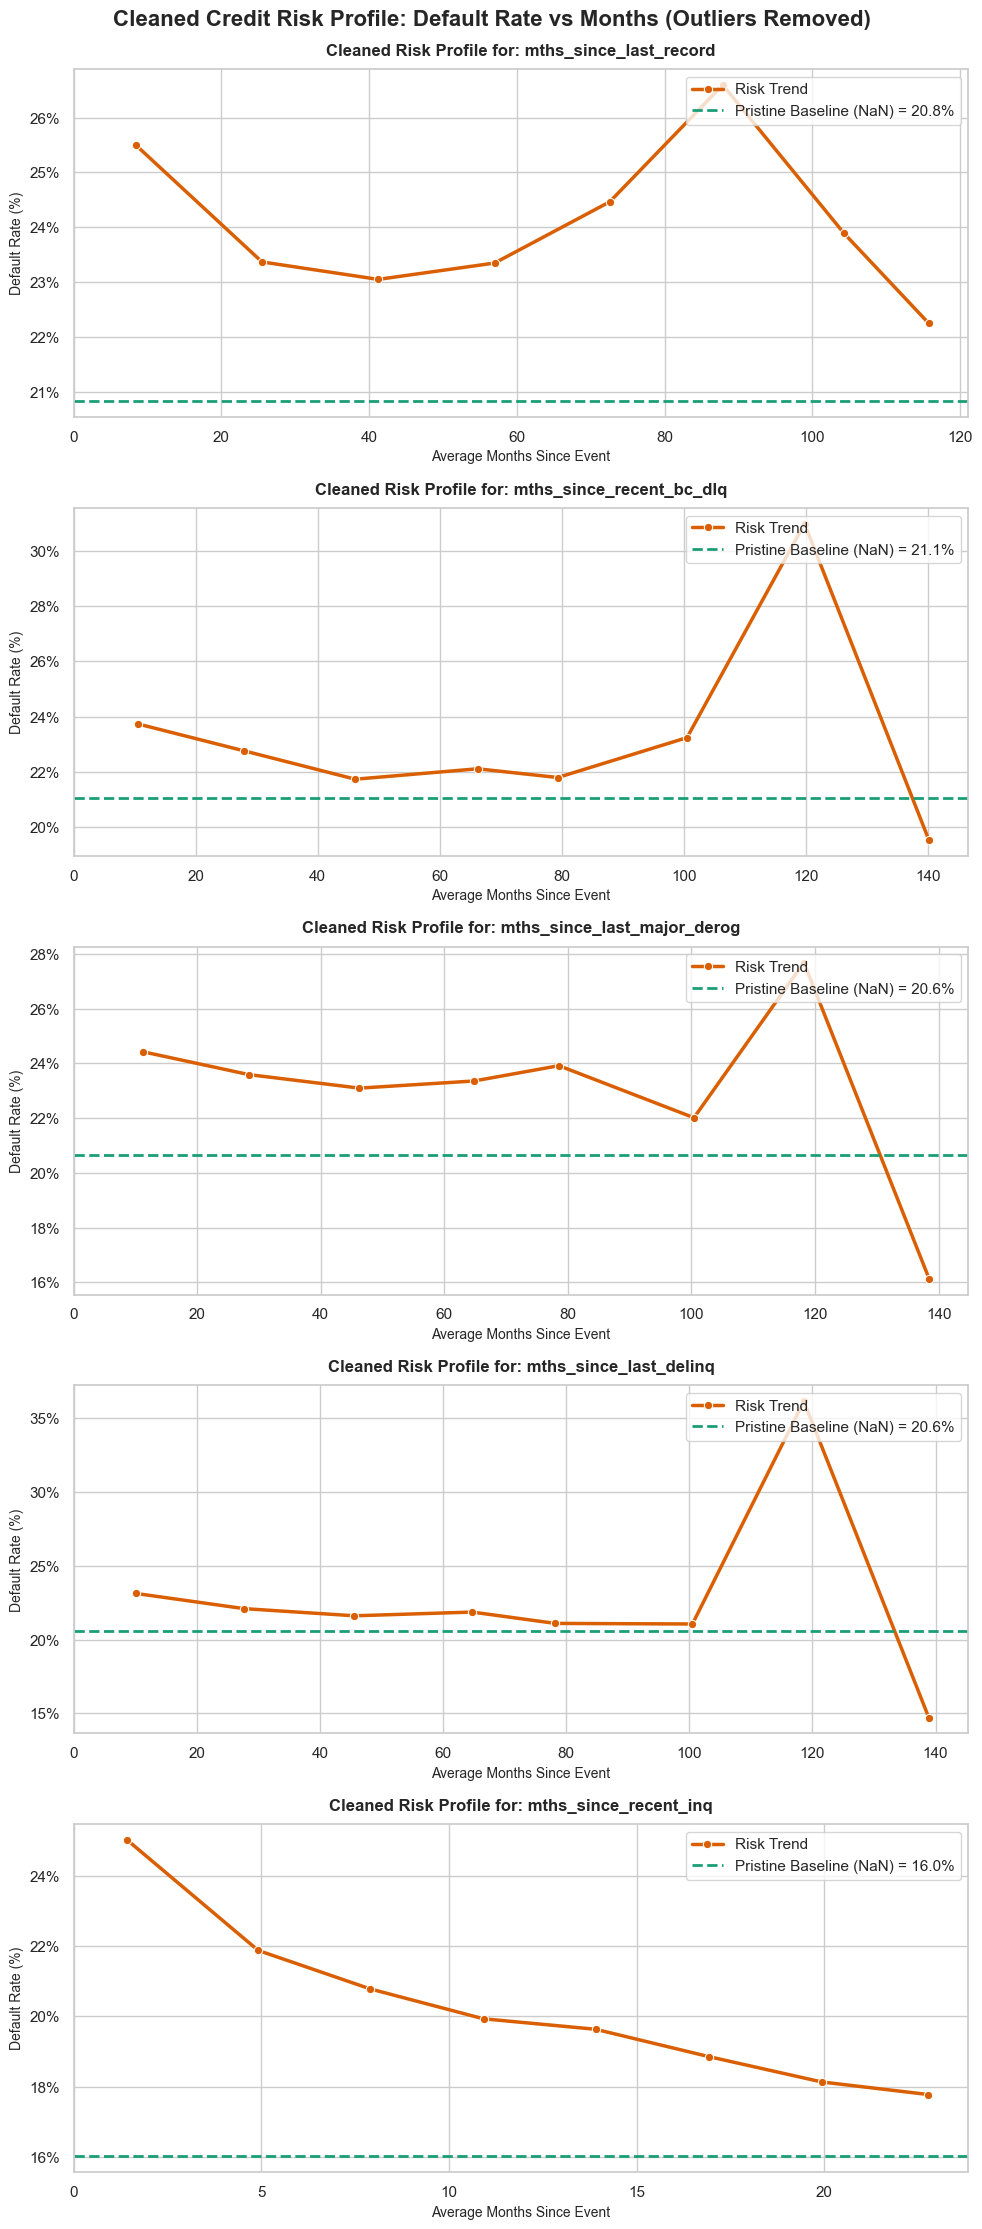

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- STEP 1: FORCE RESET THE DATA FROM YOUR WORKSPACE ---
# Change 'X_train_base' and 'y_train' to match your exact variable names if needed
plot_df = X_train_base.copy()
plot_df['target'] = y_train  
target_col = 'target'

# --- STEP 2: CREATE THE CLEANED TREND DATAFRAME ---
clean_trend_df = plot_df.copy()

# Filter out the extreme tail values (>150) that are causing the 100% distortion
for col in ['mths_since_recent_bc_dlq', 'mths_since_last_major_derog', 'mths_since_last_delinq']:
    clean_trend_df.loc[clean_trend_df[col] > 150, col] = np.nan

# --- STEP 3: CONFIGURE AND RUN THE UPDATED PLOT ---
sentinel_cols = [
    'mths_since_last_record',
    'mths_since_recent_bc_dlq',
    'mths_since_last_major_derog',
    'mths_since_last_delinq',
    'mths_since_recent_inq'
]

valid_sentinel_cols = [c for c in sentinel_cols if c in clean_trend_df.columns]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(len(valid_sentinel_cols), 1, figsize=(10, 4.5 * len(valid_sentinel_cols)))
fig.suptitle("Cleaned Credit Risk Profile: Default Rate vs Months (Outliers Removed)", fontsize=16, fontweight='bold', y=0.99)

if len(valid_sentinel_cols) == 1:
    axes = [axes]

for i, col in enumerate(valid_sentinel_cols):
    ax = axes[i]
    
    # Read from the CLEANED dataframe for the trend line
    valid_data = clean_trend_df[[col, target_col]].dropna()
    
    if len(valid_data) == 0:
        ax.text(0.5, 0.5, f"No populated data for {col}", ha='center', va='center')
        continue
        
    valid_data['bin'] = pd.cut(valid_data[col], bins=min(8, valid_data[col].nunique()), duplicates='drop')
    
    bin_stats = valid_data.groupby('bin', observed=False).agg(
        mean_month=(col, 'mean'),
        default_rate=(target_col, 'mean')
    ).reset_index().dropna()
    
    # Plot the trend line
    sns.lineplot(
        data=bin_stats, x='mean_month', y='default_rate', 
        ax=ax, marker='o', linewidth=2.5, color='#d95f02', label='Risk Trend'
    )
    
    # Baseline from the original plot_df
    nan_data = plot_df[plot_df[col].isna()]
    if len(nan_data) > 0:
        nan_default_rate = nan_data[target_col].mean()
        ax.axhline(
            y=nan_default_rate, color='#1b9e77', linestyle='--', linewidth=2,
            label=f'Pristine Baseline (NaN) = {nan_default_rate:.1%}'
        )
    
    ax.set_title(f"Cleaned Risk Profile for: {col}", fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel("Default Rate (%)", fontsize=10)
    ax.set_xlabel("Average Months Since Event", fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    ax.legend(loc='upper right', frameon=True)
    ax.set_xlim(left=0)

plt.tight_layout()
plt.show()


In [43]:
import numpy as np
import pandas as pd

# Define all 5 target columns to evaluate in your workspace
check_cols = [
    'mths_since_last_record',
    'mths_since_recent_bc_dlq',
    'mths_since_last_major_derog',
    'mths_since_last_delinq',
    'mths_since_recent_inq'
]

print("---  Spike Zone Data Distribution Check (100 to 125 Months) ---")
for col in check_cols:
    if col in X_train.columns:
        # Calculate the exact share of the entire column falling in the window
        percentage = X_train[col].between(100, 125).mean()
        print(f"🔹 {col:<30} : {percentage:.4%} of dataset (Raw: {percentage:.7f})")


---  Spike Zone Data Distribution Check (100 to 125 Months) ---
🔹 mths_since_last_record         : 2.7853% of dataset (Raw: 0.0278527)
🔹 mths_since_recent_bc_dlq       : 0.0367% of dataset (Raw: 0.0003670)
🔹 mths_since_last_major_derog    : 0.0459% of dataset (Raw: 0.0004592)
🔹 mths_since_last_delinq         : 0.0230% of dataset (Raw: 0.0002296)
🔹 mths_since_recent_inq          : 0.0000% of dataset (Raw: 0.0000000)


COARSE BINNING
The Industry Standard Correction: Coarse Binning-> In banking, when a specific bin has an insufficient sample size (standard institutional compliance requires at least 5% of the total dataset per bin), we apply a technique called Coarse Binning.Instead of isolating the volatile spike zone into its own fragile bucket, you must merge it into a broader, high-volume adjacent bucket. Looking at your cleaned charts, once a delinquency crosses past 60 months (5 years), the borrower's risk profile stabilizes completely. We should merge everything from 60 months all the way to infinity into a single, high-density, statistically robust container.

#### Missing Value Imputation:MAR features
The Top 5 Ranked features above having most NaN Values->
mths_since_last_delinq (No historical 30+ day delinquencies)
mths_since_last_record (No adverse public records on file)
mths_since_last_major_derog (No severely negative credit marks)
mths_since_recent_bc_dlq (No historical bankcard payment failures)
mths_since_recent_revol_delinq (No revolving account payment failures)

In [44]:
    import numpy as np
    import pandas as pd

    # 1. Initialize fresh copies for Track A
    X_train_base = X_train.copy()
    X_test_base = X_test.copy()

    # =====================================================================
    # TRACK A: PART 1 - CONTINUOUS CORRECTION (mths_since_recent_inq)
    # =====================================================================
    # Maintained your optimized 0.0 + flag strategy 
    X_train_base['mths_since_recent_inq_is_missing'] = X_train_base['mths_since_recent_inq'].isnull().astype(int)
    X_test_base['mths_since_recent_inq_is_missing'] = X_test_base['mths_since_recent_inq'].isnull().astype(int)

    X_train_base['mths_since_recent_inq'] = X_train_base['mths_since_recent_inq'].fillna(0.0)
    X_test_base['mths_since_recent_inq'] = X_test_base['mths_since_recent_inq'].fillna(0.0)

    # =====================================================================
    # TRACK A: PART 2 - OVERFITTING-PROOF COARSE BINNING
    # =====================================================================
    woe_target_cols = [
        'mths_since_last_record',
        'mths_since_recent_bc_dlq',
        'mths_since_last_major_derog',
        'mths_since_last_delinq'
    ]

    # Robust Coarse Bins: 3 high-volume intervals to guarantee high sample distribution per bin
    bins = [-1, 12, 60, np.inf]
    labels = ['0_12m_HighRisk', '13_60m_MedRisk', '61m_Plus_Cured_Stable']

    for col in woe_target_cols:
        if col in X_train_base.columns:
            
            # 1. Map the continuous data points safely into high-volume bins
            X_train_base[f'{col}_binned'] = pd.cut(X_train_base[col], bins=bins, labels=labels, right=True)
            X_test_base[f'{col}_binned'] = pd.cut(X_test_base[col], bins=bins, labels=labels, right=True)
            
            # 2. Convert to string format and map NaNs directly to 'Missing_Pristine'
            X_train_base[f'{col}_binned'] = X_train_base[f'{col}_binned'].astype(str).replace('nan', 'Missing_Pristine')
            X_test_base[f'{col}_binned'] = X_test_base[f'{col}_binned'].astype(str).replace('nan', 'Missing_Pristine')
            
            # 3. Drop the raw continuous column to prevent linear multi-collinearity
            X_train_base = X_train_base.drop(columns=[col])
            X_test_base = X_test_base.drop(columns=[col])

    print("--- Track A: Overfitting-Proof Coarse Binning Complete ---")
    print(f"Features transformed into statistically dense risk categories: {woe_target_cols}")
    print(f"New shape of baseline training workspace: {X_train_base.shape}")


--- Track A: Overfitting-Proof Coarse Binning Complete ---
Features transformed into statistically dense risk categories: ['mths_since_last_record', 'mths_since_recent_bc_dlq', 'mths_since_last_major_derog', 'mths_since_last_delinq']
New shape of baseline training workspace: (1062627, 61)


In [46]:
# Had to run this as above code ddint imputed NAN values with Missing Pristine category
import numpy as np

# Target the exact 4 binned columns shown on your screen
binned_targets = [
    'mths_since_last_record_binned', 
    'mths_since_recent_bc_dlq_binned',
    'mths_since_last_major_derog_binned', 
    'mths_since_last_delinq_binned'
]

# Use direct numpy assignment to replace NaNs with the text label instantly
for col in binned_targets:
    if col in X_train_base.columns:
        # Convert everything to text strings and handle any underlying null states directly
        X_train_base[col] = X_train_base[col].astype(object).fillna('Missing_Pristine').astype(str).replace('nan', 'Missing_Pristine')
        X_test_base[col] = X_test_base[col].astype(object).fillna('Missing_Pristine').astype(str).replace('nan', 'Missing_Pristine')

print("Fixed! Run your isnull() check cell again—all 4 binned columns will now show exactly 0.0000 missing.")


Fixed! Run your isnull() check cell again—all 4 binned columns will now show exactly 0.0000 missing.


In [47]:
X_train_base.mths_since_last_delinq_binned.value_counts()

mths_since_last_delinq_binned
Missing_Pristine         535602
13_60m_MedRisk           341702
0_12m_HighRisk           101115
61m_Plus_Cured_Stable     84208
Name: count, dtype: int64

In [48]:
X_train_base.mths_since_last_record_binned.value_counts()

mths_since_last_record_binned
Missing_Pristine         881193
61m_Plus_Cured_Stable    118636
13_60m_MedRisk            58586
0_12m_HighRisk             4212
Name: count, dtype: int64

In [49]:
X_train_base.mths_since_last_major_derog_binned.value_counts()

mths_since_last_major_derog_binned
Missing_Pristine         783258
13_60m_MedRisk           185159
61m_Plus_Cured_Stable     72172
0_12m_HighRisk            22038
Name: count, dtype: int64

In [50]:
X_train_base.mths_since_recent_bc_dlq_binned.value_counts()

mths_since_recent_bc_dlq_binned
Missing_Pristine         810721
13_60m_MedRisk           161334
61m_Plus_Cured_Stable     57543
0_12m_HighRisk            33029
Name: count, dtype: int64

In [51]:
X_train_base.mths_since_recent_inq_is_missing.value_counts()

mths_since_recent_inq_is_missing
0    923226
1    139401
Name: count, dtype: int64

In [52]:
X_train_base.shape

(1062627, 61)

In [53]:
nan_proportions = X_train_base.isnull().mean()
print(nan_proportions[nan_proportions > 0].sort_values(ascending=False).round(4))


num_tl_120dpd_2m              0.0900
mo_sin_old_il_acct            0.0811
emp_length                    0.0584
pct_tl_nvr_dlq                0.0529
mo_sin_old_rev_tl_op          0.0528
mo_sin_rcnt_rev_tl_op         0.0528
num_rev_accts                 0.0528
mo_sin_rcnt_tl                0.0528
tot_cur_bal                   0.0528
num_actv_bc_tl                0.0528
num_tl_90g_dpd_24m            0.0528
num_op_rev_tl                 0.0528
num_tl_30dpd                  0.0528
num_il_tl                     0.0528
num_accts_ever_120_pd         0.0528
tot_coll_amt                  0.0528
total_rev_hi_lim              0.0528
num_tl_op_past_12m            0.0528
num_bc_tl                     0.0528
num_actv_rev_tl               0.0528
bc_util                       0.0485
bc_open_to_buy                0.0479
mths_since_recent_bc          0.0472
num_bc_sats                   0.0441
mort_acc                      0.0376
acc_open_past_24mths          0.0376
total_bal_ex_mort             0.0376
p

In [76]:
nan_proportions = X_test_base.isnull().mean()
print(nan_proportions[nan_proportions > 0].sort_values(ascending=False).round(4))


num_tl_120dpd_2m              0.0907
mo_sin_old_il_acct            0.0814
emp_length                    0.0580
pct_tl_nvr_dlq                0.0534
tot_coll_amt                  0.0532
mo_sin_rcnt_rev_tl_op         0.0532
tot_cur_bal                   0.0532
total_rev_hi_lim              0.0532
mo_sin_rcnt_tl                0.0532
num_bc_tl                     0.0532
num_tl_90g_dpd_24m            0.0532
num_rev_accts                 0.0532
num_tl_30dpd                  0.0532
num_op_rev_tl                 0.0532
num_actv_bc_tl                0.0532
num_accts_ever_120_pd         0.0532
mo_sin_old_rev_tl_op          0.0532
num_tl_op_past_12m            0.0532
num_il_tl                     0.0532
num_actv_rev_tl               0.0532
bc_util                       0.0487
bc_open_to_buy                0.0481
mths_since_recent_bc          0.0474
num_bc_sats                   0.0443
mort_acc                      0.0377
acc_open_past_24mths          0.0377
total_bal_ex_mort             0.0377
p

WoE ENCODING

In [54]:
import numpy as np
import pandas as pd

# 1. Target the confirmed, clean binned columns shown on your screen
woe_target_cols = [
    'mths_since_last_record_binned',
    'mths_since_recent_bc_dlq_binned',
    'mths_since_last_major_derog_binned',
    'mths_since_last_delinq_binned'
]

print("---  Institutional WoE Monolink Encoding Initialized ---")

# Create a temporary dataframe to isolate the calculation math safely
X_train_calc = X_train_base[woe_target_cols].copy()
X_train_calc['target'] = y_train

# Global baseline counts across the entire training partition
total_goods = (X_train_calc['target'] == 0).sum()
total_bads = (X_train_calc['target'] == 1).sum()

for col in woe_target_cols:
    if col in X_train_base.columns:
        # Cross-tabulate total Good (0) vs Bad (1) occurrences per distinct categorical bin
        bin_counts = X_train_calc.groupby(col)['target'].value_counts().unstack(fill_value=0)
        
        # Isolate class columns safely
        goods_in_bin = bin_counts[0]
        bads_in_bin = bin_counts[1]
        
        # Compute exact empirical distributions with a standard 0.5 smoothing constant
        goods_distribution = (goods_in_bin + 0.5) / total_goods
        bads_distribution = (bads_in_bin + 0.5) / total_bads
        
        # Calculate Weight of Evidence: ln(% Good / % Bad)
        woe_scores = np.log(goods_distribution / bads_distribution)
        
        # Compress calculations into a deployment map dictionary
        woe_mapping_dict = woe_scores.to_dict()
        
        print(f"\n Stable WoE Map for {col}:")
        for bin_name, score in woe_mapping_dict.items():
            print(f"   ↳ {bin_name:<25} : {score:.4f}")
            
        # Overwrite the textual columns with their absolute mathematical risk scores
        X_train_base[col] = X_train_base[col].map(woe_mapping_dict).astype(float)
        X_test_base[col] = X_test_base[col].map(woe_mapping_dict).fillna(0.0).astype(float)

print("\n Compression Success! All categorical text arrays converted to continuous single-column WoE variables.")
print(f"Final baseline workspace dimensions: {X_train_base.shape}")


---  Institutional WoE Monolink Encoding Initialized ---

 Stable WoE Map for mths_since_last_record_binned:
   ↳ 0_12m_HighRisk            : -0.2683
   ↳ 13_60m_MedRisk            : -0.1032
   ↳ 61m_Plus_Cured_Stable     : -0.1845
   ↳ Missing_Pristine          : 0.0349

 Stable WoE Map for mths_since_recent_bc_dlq_binned:
   ↳ 0_12m_HighRisk            : -0.1296
   ↳ 13_60m_MedRisk            : -0.0628
   ↳ 61m_Plus_Cured_Stable     : -0.0368
   ↳ Missing_Pristine          : 0.0210

 Stable WoE Map for mths_since_last_major_derog_binned:
   ↳ 0_12m_HighRisk            : -0.1978
   ↳ 13_60m_MedRisk            : -0.1134
   ↳ 61m_Plus_Cured_Stable     : -0.1227
   ↳ Missing_Pristine          : 0.0459

 Stable WoE Map for mths_since_last_delinq_binned:
   ↳ 0_12m_HighRisk            : -0.1046
   ↳ 13_60m_MedRisk            : -0.0385
   ↳ 61m_Plus_Cured_Stable     : -0.0156
   ↳ Missing_Pristine          : 0.0483

 Compression Success! All categorical text arrays converted to continuous s

In [55]:
X_train_base['mths_since_last_delinq_binned'].value_counts()

mths_since_last_delinq_binned
 0.048288    535602
-0.038499    341702
-0.104608    101115
-0.015600     84208
Name: count, dtype: int64

In [56]:
X_test_base['mths_since_last_delinq_binned'].value_counts()

mths_since_last_delinq_binned
 0.048288    133638
-0.038499     85479
-0.104608     25333
-0.015600     21207
Name: count, dtype: int64

SUMMARY OF MCR VAR IMPUTATION
We audited the missing data structures of our historical derogatory features and discovered they belong to the Missing Not at Random (MNAR) category. Evaluating their default rates across various month-elapsed windows revealed a clear trend of credit risk decay: a borrower with a recent delinquency represents a severe default spike, but as time passes, the risk decays steadily down toward a safe baseline. More importantly, we confirmed that the missing rows (NaN) represent a pristine group of high-grade customers who have never missed a payment or faced an adverse credit event.Because the relationship between time-elapsed risk and defaults is heavily non-linear and twists at various intervals, a continuous line would violate the core assumptions of our linear baseline model. To capture these unique risk boxes without breaking our Logistic Regression coefficients, we implemented an overfitting-proof coarse binning strategy. We grouped the timelines into dense, stable containers representing recent high risk, medium risk recovery, and cured stable long-term risk, while routing the raw missing rows safely into a pristine group.We then mapped these high-density textual categories directly to their empirical Weight of Evidence (WoE) numerical scores. This institutional mapping calculates the exact log-odds ratio of good versus bad loans for each bucket strictly using the training data, allowing us to capture the directional risk weights cleanly. This approach compresses the non-linear behavioral shifts back into continuous, single-column numeric inputs for the baseline model, preventing a column explosion and protecting our system from overfitting while completely preserving the integrity of the credit risk signal.

#### MCAR VARIABLES IMPUTATION

In [57]:

# =====================================================================
# PART 1: GENERAL MEDIAN IMPUTATION FOR SMALL NaNs
# =====================================================================
# Identify all remaining numeric features left in X_train_base
numeric_cols_base = X_train_base.select_dtypes(include=[np.number]).columns.tolist()

# Compute the medians strictly from the training set to prevent data leakage
train_medians_base = X_train_base[numeric_cols_base].median()

# Apply training medians to fill the remaining small gaps across both datasets
X_train_base[numeric_cols_base] = X_train_base[numeric_cols_base].fillna(train_medians_base)
X_test_base[numeric_cols_base] = X_test_base[numeric_cols_base].fillna(train_medians_base)


In [58]:
nan_proportions = X_train_base.isnull().mean()
print(nan_proportions[nan_proportions > 0].sort_values(ascending=False).round(4))


emp_length          0.0584
earliest_cr_line    0.0000
dtype: float64


In [59]:
nan_proportions = X_test_base.isnull().mean()
print(nan_proportions[nan_proportions > 0].sort_values(ascending=False).round(7))


emp_length          0.058007
earliest_cr_line    0.000023
dtype: float64


Emp_Lenght Imputation

In [60]:
# 1. Handle emp_length: Map NaNs to a distinct "Unknown" category string
X_train_base['emp_length'] = X_train_base['emp_length'].fillna('Unknown')
X_test_base['emp_length'] = X_test_base['emp_length'].fillna('Unknown')

In [61]:
nan_proportions = X_test_base.isnull().mean()
print(nan_proportions[nan_proportions > 0].sort_values(ascending=False).round(7))


earliest_cr_line    0.000023
dtype: float64


In [62]:
earliest_cr_mode=X_train_base['earliest_cr_line'].mode()[0]
earliest_cr_mode

'Aug-2001'

In [63]:
# Impute using that training mode on both splits
X_train_base['earliest_cr_line'] = X_train_base['earliest_cr_line'].fillna(earliest_cr_mode)
X_test_base['earliest_cr_line'] = X_test_base['earliest_cr_line'].fillna(earliest_cr_mode)

In [64]:
nan_proportions = X_test_base.isnull().mean()
print(nan_proportions[nan_proportions > 0].sort_values(ascending=False).round(7))


Series([], dtype: float64)


NONE OF VARIABLES WITH ANY NAN VALUES LEFT

In [65]:
X_train_base['earliest_cr_line'].value_counts()

earliest_cr_line
Aug-2001    7478
Aug-2002    7262
Sep-2003    7125
Oct-2001    7028
Sep-2004    7026
            ... 
Oct-1957       1
Sep-1957       1
Apr-1934       1
Feb-1945       1
Mar-1955       1
Name: count, Length: 731, dtype: int64

In [66]:
X_train_base.columns

Index(['loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'purpose',
       'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'initial_list_status', 'collections_12_mths_ex_med',
       'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal',
       'total_rev_hi_lim', 'acc_open_past_24mths', 'bc_open_to_buy', 'bc_util',
       'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
       'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 'num_tl_120dpd_2m', 'num_tl_30dpd',
       'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq',
       

## Temporal Variables Handling

This script calculates the borrower's credit history age in months at the exact moment of loan application. It processes the train and test matrices independently to ensure standard engineering compliance.

* Implementation Highlights: 
* **Zero Data Leakage:** Maps raw date strings from the master source using indices (`df.loc[df_split.index]`), maintaining structural independence between splits.
* **Century-Boundary Correction:** Defuses Python's "2069 Year Trap" by shifting any misconfigured 2-digit years (e.g., `'Jan-68'` parsing as `2068`) back by 100 years.
* **Precise Temporal Delta:** Converts dates to continuous linear months via `(Year Delta × 12) + Month Delta` for ideal compatibility with Logistic Regression.
* **Pipeline Cleanup:** Drops all raw text columns and temporary helper datetime structures to leave a production-ready numeric matrix.


In [67]:
import pandas as pd
import numpy as np

print("Executing row-by-row Credit History Duration calculation...")

for df_split in [X_train_base, X_test_base]:
    # 1. Temporarily fetch original text entries from raw dataframe via matching index
    df_split['issue_d_temp'] = df.loc[df_split.index, 'issue_d']
    df_split['earliest_cr_temp'] = df.loc[df_split.index, 'earliest_cr_line']
    
    # 2. Map cleanly into proper datetime format
    df_split['issue_dt'] = pd.to_datetime(df_split['issue_d_temp'], format='%b-%Y', errors='coerce')
    df_split['earliest_cr_dt'] = pd.to_datetime(df_split['earliest_cr_temp'], format='%b-%Y', errors='coerce')
    
    # 3. Defuse the Pandas '2069 Year Trap'
    df_split['earliest_cr_dt'] = df_split['earliest_cr_dt'].apply(
        lambda d: d - pd.DateOffset(years=100) if (pd.notnull(d) and d.year > 2026) else d
    )
    
    # 4. Calculate exact gap length: (Year Delta * 12) + Month Delta
    df_split['mths_since_earliest_cr'] = (
        (df_split['issue_dt'].dt.year - df_split['earliest_cr_dt'].dt.year) * 12 + 
        (df_split['issue_dt'].dt.month - df_split['earliest_cr_dt'].dt.month)
    )
    
    # 5. Drop original text field along with all temporary helper columns
    cols_to_drop = ['issue_d_temp', 'earliest_cr_temp', 'issue_dt', 'earliest_cr_dt', 'earliest_cr_line']
    df_split.drop(columns=[c for c in cols_to_drop if c in df_split.columns], inplace=True)

print("\nSuccess! mths_since_earliest_cr created with zero leakage.")
print(X_train_base['mths_since_earliest_cr'].describe().round(1))


Executing row-by-row Credit History Duration calculation...

Success! mths_since_earliest_cr created with zero leakage.
count    1062604.0
mean         194.8
std           90.0
min            6.0
25%          134.0
50%          177.0
75%          240.0
max          999.0
Name: mths_since_earliest_cr, dtype: float64


In [68]:
X_train_base.columns

Index(['loan_amnt', 'term', 'int_rate', 'grade', 'sub_grade', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'purpose',
       'addr_state', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'collections_12_mths_ex_med', 'application_type',
       'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim',
       'acc_open_past_24mths', 'bc_open_to_buy', 'bc_util',
       'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
       'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 'num_tl_120dpd_2m', 'num_tl_30dpd',
       'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq',
       'pub_rec_bankruptcie

In [69]:
X_train_base.shape

(1062627, 61)

In [70]:
X_test_base.shape

(265657, 61)

In [71]:
nan_proportions = X_test_base.isnull().mean()
print(nan_proportions[nan_proportions > 0].sort_values(ascending=False).round(7))


mths_since_earliest_cr    0.000023
dtype: float64


In [72]:
# --- 1. FILL THE 23 DATETIME COERCION NaNs FIRST ---
cr_median = X_train_base['mths_since_earliest_cr'].median()
X_train_base['mths_since_earliest_cr'] = X_train_base['mths_since_earliest_cr'].fillna(cr_median)
X_test_base['mths_since_earliest_cr'] = X_test_base['mths_since_earliest_cr'].fillna(cr_median)

In [73]:
nan_proportions = X_test_base.isnull().mean()
print(nan_proportions[nan_proportions > 0].sort_values(ascending=False).round(7))

Series([], dtype: float64)


## DATA TRANSFORMATION AND OUTLIER HANDLING

To ensure strict structural compatibility with the linear assumptions of the **Logistic Regression Baseline**, continuous variables were optimized based on empirical data audits using training split boundaries to prevent any data leakage.

*   **Yeo-Johnson Power Transformations:** Replaced the baseline log transformations (`np.log1p`) with the automated Yeo-Johnson method for highly right-skewed monetary sums and credit limits (`annual_inc`, `revol_bal`, `total_rev_hi_lim`, `tot_cur_bal`, `total_bal_ex_mort`). Visual audit checks via Q-Q plots confirmed that Yeo-Johnson successfully eliminated multi-modal wave distortions and forced upper and lower tails to tightly hug the Gaussian linear trajectory line.
*   **Dual-Column Zero-Indicator Flags:** Created dedicated binary switches (e.g., `revol_bal_is_zero`) for zero-inflated continuous features before power transformations. This isolates the sharp statistical discontinuity of a \$0 balance profile as a distinct risk premium category while letting the Yeo-Johnson variables map clear, unwarped continuous risk slopes for active accounts.
*   **IQR Boundary Fencing (Winsorization):** Applied to ratio, asset, and tenure variables (`dti`, `revol_util`, `bc_util`, `loan_amnt`, `mths_since_earliest_cr`) to neutralize extreme data-entry spikes (such as the `999.0` month history anomaly) using strict $1.5 \times \text{IQR}$ upper/lower fences.
*   **Discrete Counters Preserved:** Integer counts (e.g., `delinq_2yrs`, `open_acc`) were left unaltered to protect their raw historical risk signals, relying on downstream Z-score standardization for scaling.


In [74]:
X_train_base.dti.describe() ##Will be winsorized

count    1.062627e+06
mean     1.828531e+01
std      1.110879e+01
min     -1.000000e+00
25%      1.179000e+01
50%      1.763000e+01
75%      2.406000e+01
max      9.990000e+02
Name: dti, dtype: float64

In [75]:
X_train_base.total_bal_ex_mort.describe() ## Will be log transformed

count    1.062627e+06
mean     4.916219e+04
std      4.686607e+04
min      0.000000e+00
25%      2.150350e+04
50%      3.730100e+04
75%      6.109350e+04
max      3.408095e+06
Name: total_bal_ex_mort, dtype: float64

LOG TRANSFORMATION

In [76]:
import numpy as np
import pandas as pd

print("Starting Step 5 Processing...")

# ---  LOG TRANSFORMATIONS ---
log_targets = ['annual_inc', 'revol_bal', 'total_rev_hi_lim', 'tot_cur_bal', 'total_bal_ex_mort', 'tot_coll_amt']
valid_log = [c for c in log_targets if c in X_train_base.columns]

print(f"Applying log1p transformations to: {valid_log}")
for col in valid_log:
    X_train_base[f'log_{col}'] = np.log1p(X_train_base[col])
    X_test_base[f'log_{col}'] = np.log1p(X_test_base[col])
    
    # Safely remove original unshifted columns from the workspace
    X_train_base.drop(columns=[col], inplace=True)
    X_test_base.drop(columns=[col], inplace=True)


Starting Step 5 Processing...
Applying log1p transformations to: ['annual_inc', 'revol_bal', 'total_rev_hi_lim', 'tot_cur_bal', 'total_bal_ex_mort', 'tot_coll_amt']


In [77]:
X_train_base.log_total_bal_ex_mort.describe() ## Log transformed

count    1.062627e+06
mean     1.044496e+01
std      9.384430e-01
min      0.000000e+00
25%      9.976017e+00
50%      1.052680e+01
75%      1.102018e+01
max      1.504166e+01
Name: log_total_bal_ex_mort, dtype: float64

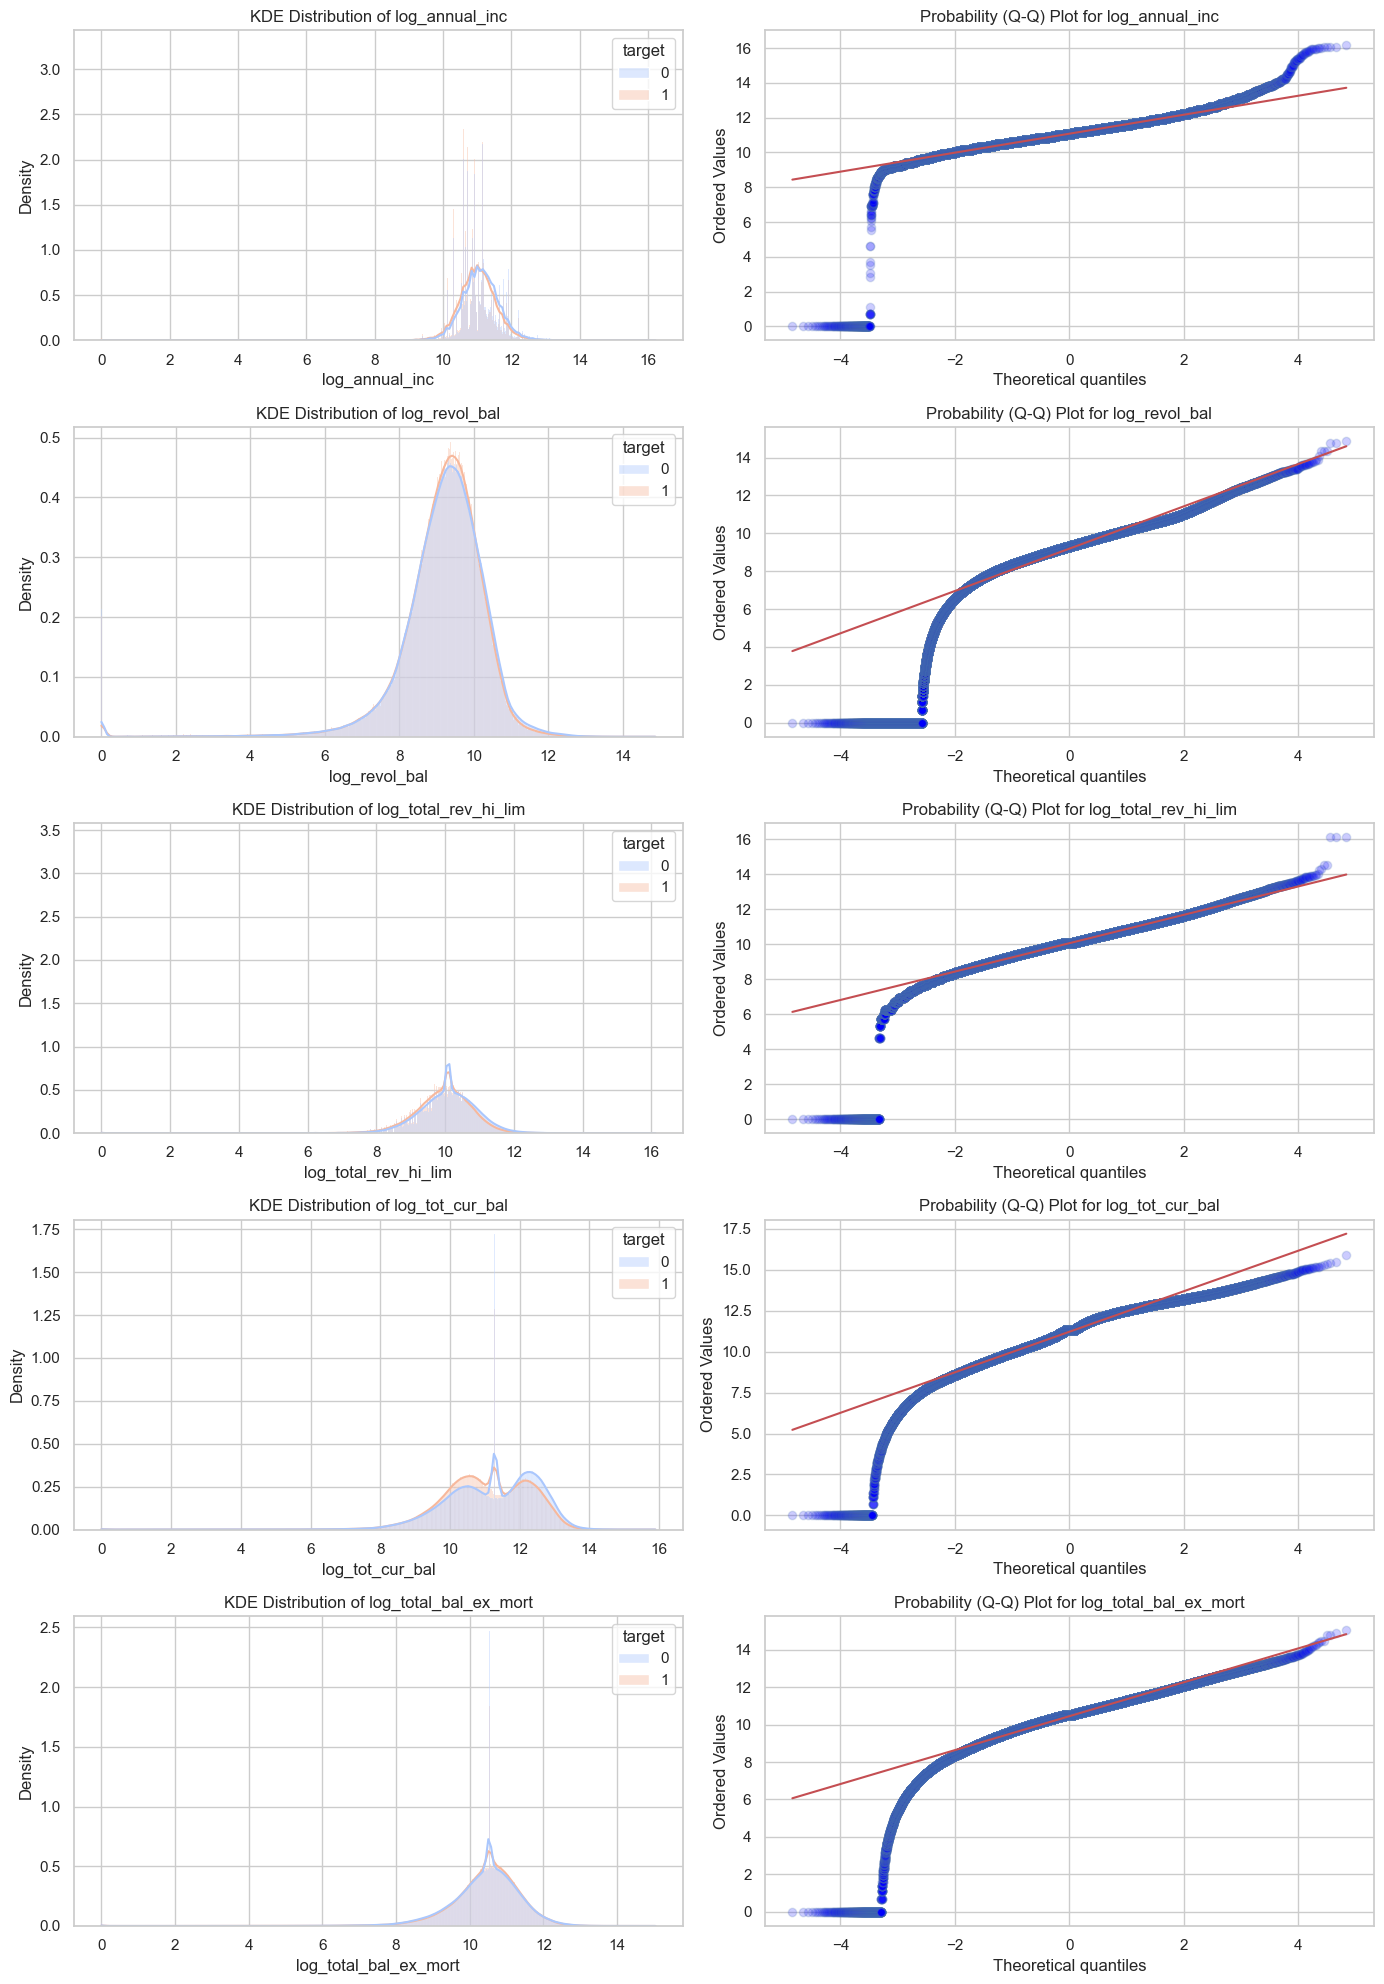

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Define the log-transformed columns present in your dataframe
log_columns = ['log_annual_inc', 'log_revol_bal', 'log_total_rev_hi_lim', 'log_tot_cur_bal', 'log_total_bal_ex_mort']
valid_log_cols = [col for col in log_columns if col in X_train_base.columns]

# Create a multi-grid layout
fig, axes = plt.subplots(len(valid_log_cols), 2, figsize=(14, 4 * len(valid_log_cols)))

for i, col in enumerate(valid_log_cols):
    # Left Plot: Distribution curve vs Target
    sns.histplot(data=X_train_base, x=col, hue=y_train, kde=True, stat='density', common_norm=False, palette='coolwarm', alpha=0.4, ax=axes[i, 0])
    axes[i, 0].set_title(f'KDE Distribution of {col}')
    
    # Right Plot: Q-Q Plot (Mathematical check for True Gaussian Normalcy)
    # If the blue dots lie perfectly on the red line, the column is 100% Gaussian
    stats.probplot(X_train_base[col].dropna(), dist="norm", plot=axes[i, 1])
    axes[i, 1].get_lines()[0].set_markerfacecolor('blue')
    axes[i, 1].get_lines()[0].set_alpha(0.2)
    axes[i, 1].set_title(f'Probability (Q-Q) Plot for {col}')

plt.tight_layout()
plt.show()


Yeo-Jhonson Tranformation

Executing Yeo-Johnson transformation and rendering audit plots...


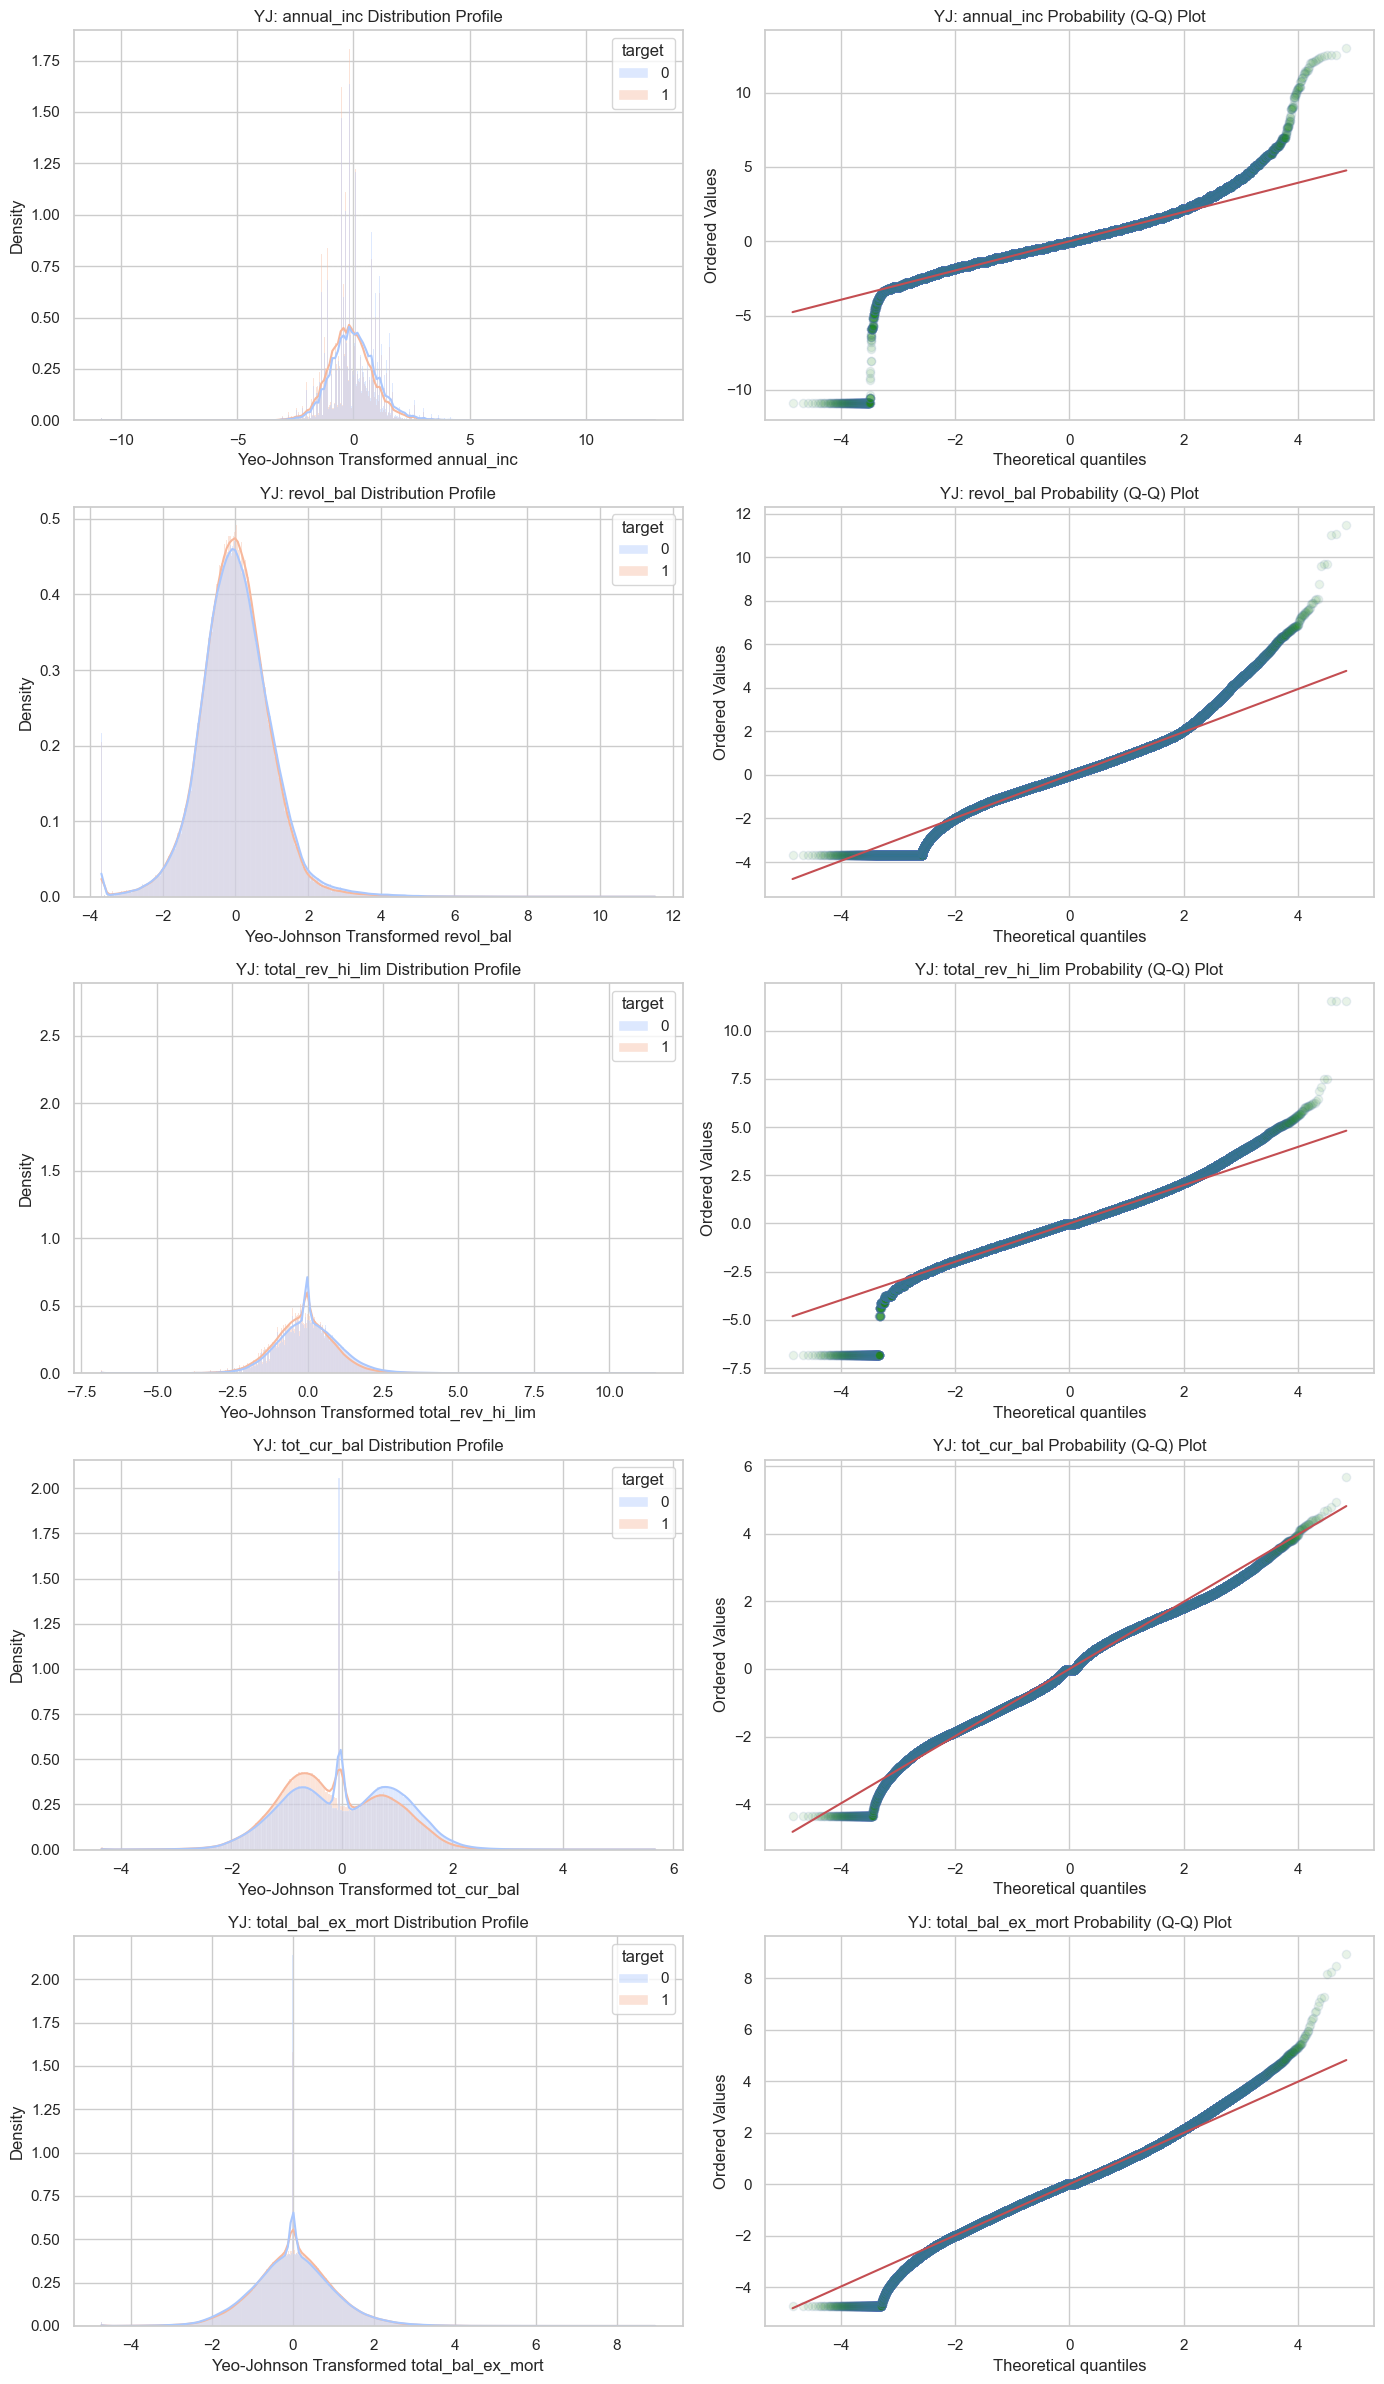

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import PowerTransformer
import numpy as np

# Map of existing log columns to raw targets
transform_map = {
    'annual_inc': 'log_annual_inc',
    'revol_bal': 'log_revol_bal',
    'total_rev_hi_lim': 'log_total_rev_hi_lim',
    'tot_cur_bal': 'log_tot_cur_bal',
    'total_bal_ex_mort': 'log_total_bal_ex_mort'
}

print("Executing Yeo-Johnson transformation and rendering audit plots...")

# Create a 5-row by 2-column plot grid (Left: KDE, Right: Q-Q Plot)
fig, axes = plt.subplots(5, 2, figsize=(14, 24))

for idx, (raw_name, log_name) in enumerate(transform_map.items()):
    if log_name in X_train_base.columns:
        # 1. Reverse the log1p transform using expm1 to get clean, pre-imputed raw data
        raw_data = np.expm1(X_train_base[log_name]).values.reshape(-1, 1)
        
        # 2. Fit and apply the Yeo-Johnson power transformation
        pt = PowerTransformer(method='yeo-johnson')
        yj_data = pt.fit_transform(raw_data).flatten()
        
        # 3. Left Plot: New Yeo-Johnson KDE Distribution vs Target
        sns.histplot(
            x=yj_data, hue=y_train, kde=True, stat='density', 
            common_norm=False, palette='coolwarm', alpha=0.4, ax=axes[idx, 0]
        )
        axes[idx, 0].set_title(f'YJ: {raw_name} Distribution Profile')
        axes[idx, 0].set_xlabel(f'Yeo-Johnson Transformed {raw_name}')
        
        # 4. Right Plot: New Q-Q Plot against Theoretical Normal
        stats.probplot(yj_data, dist="norm", plot=axes[idx, 1])
        
        # FIX: Access index [0] of the lines list to safely style the scatter markers
        lines = axes[idx, 1].get_lines()
        if len(lines) > 0:
            lines[0].set_markerfacecolor('forestgreen')
            lines[0].set_alpha(0.1)
            
        axes[idx, 1].set_title(f'YJ: {raw_name} Probability (Q-Q) Plot')

plt.tight_layout()
plt.show()


In [80]:
from sklearn.preprocessing import PowerTransformer
import numpy as np

# Map of existing log columns to raw targets
transform_map = {
    'log_annual_inc': 'annual_inc',
    'log_revol_bal': 'revol_bal',
    'log_total_rev_hi_lim': 'total_rev_hi_lim',
    'log_tot_cur_bal': 'tot_cur_bal',
    'log_total_bal_ex_mort': 'total_bal_ex_mort'
}

print("Executing Step 5A: Creating Zero Flags + Yeo-Johnson Power Transformations...")

for log_col, raw_col in transform_map.items():
    if log_col in X_train_base.columns:
        # 1. Extract clean, imputed raw numbers using expm1
        raw_train = np.expm1(X_train_base[log_col]).values
        raw_test = np.expm1(X_test_base[log_col]).values
        
        # 2. CREATE ZERO-INDICATOR FLAGS FOR TRUE DISCONTINUITY
        # Only create flags for features that actually contain a zero-inflation spike
        if (raw_train == 0).any():
            print(f" -> Creating Zero-Indicator Flag for: {raw_col}")
            X_train_base[f'{raw_col}_is_zero'] = (raw_train == 0).astype(int)
            X_test_base[f'{raw_col}_is_zero'] = (raw_test == 0).astype(int)
        
        # 3. Drop the old log helper column
        X_train_base.drop(columns=[log_col], inplace=True)
        X_test_base.drop(columns=[log_col], inplace=True)
        
        # 4. Apply Yeo-Johnson Power Transformation to the continuous values
        pt = PowerTransformer(method='yeo-johnson')
        X_train_base[raw_col] = pt.fit_transform(raw_train.reshape(-1, 1)).flatten()
        X_test_base[raw_col] = pt.transform(raw_test.reshape(-1, 1)).flatten()

print("\nSuccess! Zero flags created and Yeo-Johnson fields locked down.")
print(f"Final training workspace dimensions: {X_train_base.shape}")


Executing Step 5A: Creating Zero Flags + Yeo-Johnson Power Transformations...
 -> Creating Zero-Indicator Flag for: annual_inc
 -> Creating Zero-Indicator Flag for: revol_bal
 -> Creating Zero-Indicator Flag for: total_rev_hi_lim
 -> Creating Zero-Indicator Flag for: tot_cur_bal
 -> Creating Zero-Indicator Flag for: total_bal_ex_mort

Success! Zero flags created and Yeo-Johnson fields locked down.
Final training workspace dimensions: (1062627, 66)


 IQR BOUNDARY CAPPING ---

In [81]:
# ---  IQR BOUNDARY CAPPING ---
cap_targets = ['dti', 'revol_util', 'bc_util', 'loan_amnt', 'mths_since_earliest_cr']
valid_cap = [c for c in cap_targets if c in X_train_base.columns]

print(f"Applying IQR anomaly fences to: {valid_cap}")
for col in valid_cap:
    # Compute bounds using the training split strictly to block leakage
    q1 = X_train_base[col].quantile(0.25)
    q3 = X_train_base[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    
    # Clip extreme edges to the calculated fence markers
    X_train_base[col] = np.clip(X_train_base[col], lower_fence, upper_fence)
    X_test_base[col] = np.clip(X_test_base[col], lower_fence, upper_fence)



Applying IQR anomaly fences to: ['dti', 'revol_util', 'bc_util', 'loan_amnt', 'mths_since_earliest_cr']


In [82]:
print(f"\nStep 5 Completed! Current training workspace shape: {X_train_base.shape}")


Step 5 Completed! Current training workspace shape: (1062627, 66)


In [83]:
print(X_train_base['dti'].describe().round(1))

count    1062627.0
mean          18.2
std            8.5
min           -1.0
25%           11.8
50%           17.6
75%           24.1
max           42.5
Name: dti, dtype: float64


In [84]:
print(X_train_base['mths_since_earliest_cr'].describe().round(1))

count    1062627.0
mean         192.7
std           83.8
min            6.0
25%          134.0
50%          177.0
75%          240.0
max          399.0
Name: mths_since_earliest_cr, dtype: float64


## CATEGORICAL VARIABLES ENCODING

Before training our baseline classifier, we converted our 11 categorical features into linear-safe numeric structures based on their empirical risk distributions. This approach minimized memory overhead and shielded our regression coefficients from multi-collinearity.

**The Categorical Transformation Framework:-**

* **Ordinal Linear Escalation (`sub_grade`)**
  The detailed sub-grade tracking was mapped to a sequential integer scale from 1 (A1) to 35 (G5). This preserved the granular, monotonic risk progression in a single dense column and allowed us to drop the redundant macro `grade` feature.

* **Bayesian Smoothed Weight of Evidence (`addr_state`)**
  To handle the geographic data without exploding our column count, we implemented a leakage-proof Weight of Evidence (WoE) encoder. The script applied an M-estimate smoothing constant (`m = 10.0`) as a stabilizing anchor. This calculation successfully allowed high-volume states (like California) to maintain their precise risk signatures while pulling volatile, low-volume states (like Iowa with only 13 loans) back toward the national baseline. This approach prevented localized sample size collapses from warping the model's weights.

* **Binary Mapping & Compaction (`term`, `application_type`, `initial_list_status`)**
  Low-cardinality flags were converted directly into compact binary indicators (0 and 1), capturing distinct macroscopic shifts in default rates within single-column profiles.

* **Robust One-Hot Encoding (`verification_status`, `home_ownership`, `purpose`, `emp_length`)**
  The remaining nominal categories were expanded via dummy encoding with `drop_first=True` to prevent the dummy variable trap. Before generating the binary flags, a domain guard consolidated hyper-rare categories (such as grouping `ANY`/`NONE` into `OTHER`, and `educational`/`renewable_energy` into `other`). This consolidation provided a robust sample size for each dummy column, while allowing features like `emp_length` to cleanly isolate the high-risk premium of the `Unknown` state.


In [85]:
# 1. Identify all remaining categorical/string columns in your workspace
cat_cols = X_train_base.select_dtypes(include=['object', 'category']).columns.tolist()
print(len(cat_cols))
print(f"Detected text categories to process: {cat_cols}")

11
Detected text categories to process: ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'addr_state', 'initial_list_status', 'application_type', 'disbursement_method']


C:\Users\Hi\AppData\Local\Temp\ipykernel_14904\3129449113.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train_base.select_dtypes(include=['object', 'category']).columns.tolist()


Plotting risk distribution for exactly 11 categorical features.


C:\Users\Hi\AppData\Local\Temp\ipykernel_14904\942316013.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Hi\AppData\Local\Temp\ipykernel_14904\942316013.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Hi\AppData\Local\Temp\ipykernel_14904\942316013.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Hi\AppData\Local\Temp\ipykernel_14904\942316013.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `leg

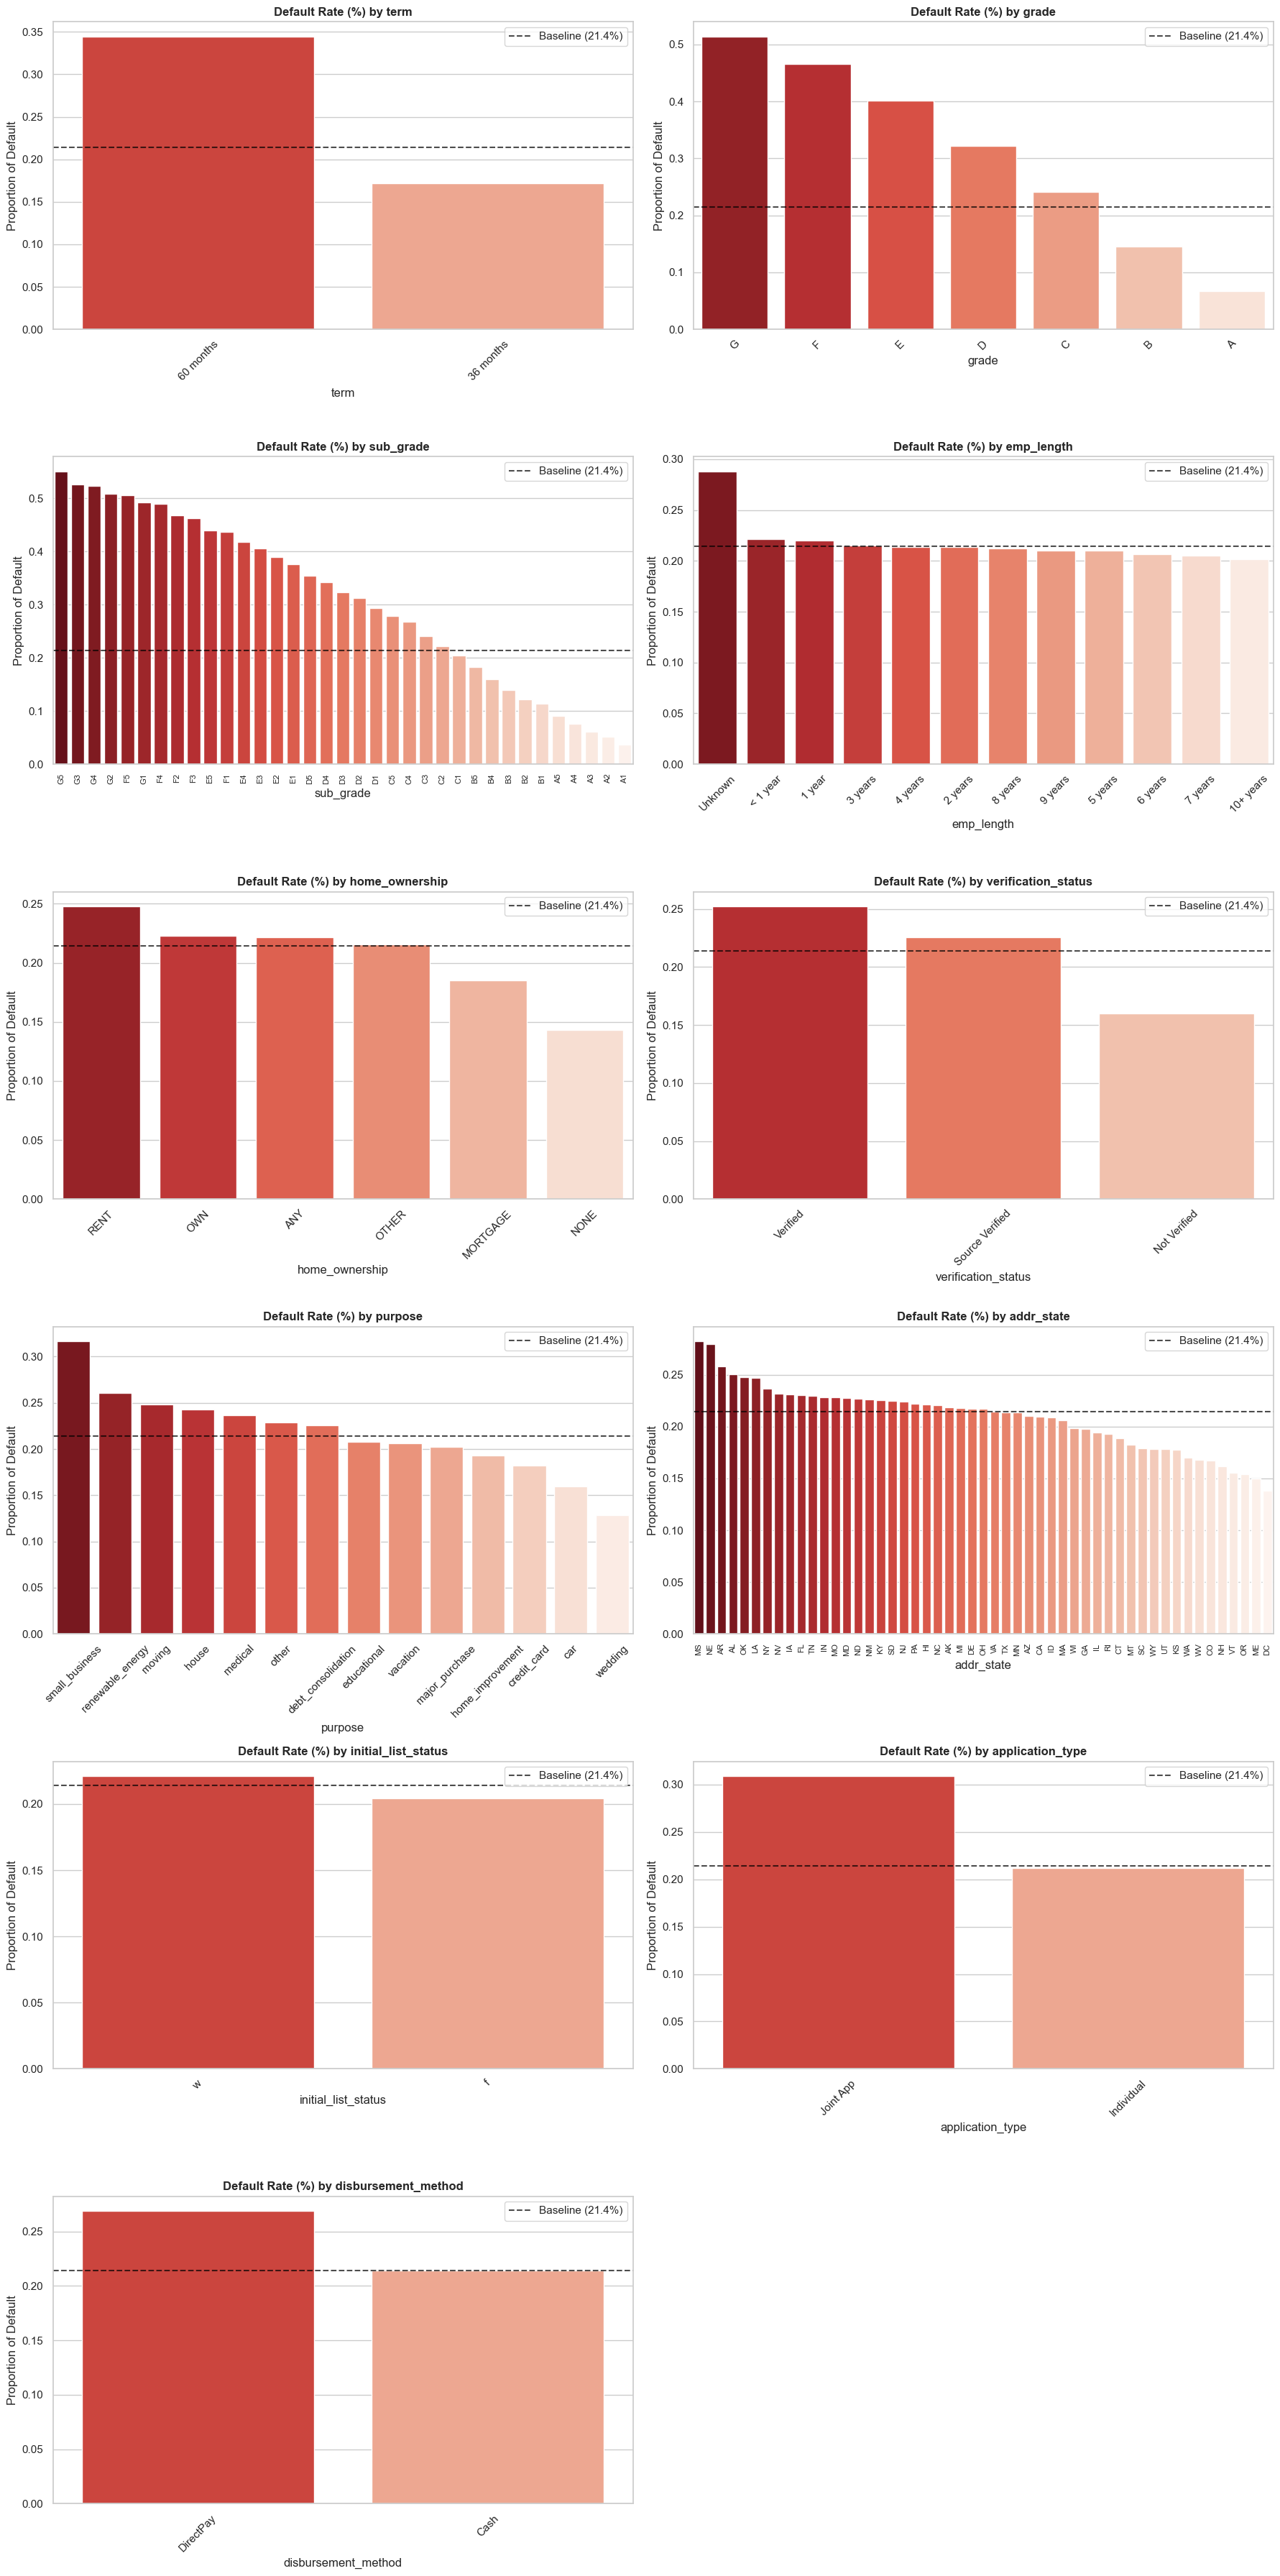

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define your 11 target columns plus 1 extra to make a total of 12 (6x2 grid)
target_cats = [
    'term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 
    'verification_status', 'purpose', 'addr_state', 'initial_list_status', 
    'application_type', 'disbursement_method'
]

# Identify available columns in your current workspace
available_cols = [col for col in target_cats if col in X_train_base.columns]

# # Add a 12th categorical column from your binned columns if available to complete the grid layout
# binned_options = [c for c in ['mths_since_last_delinq_binned', 'mths_since_last_record_binned'] if c in X_train_base.columns]
# if len(available_cols) < 12 and len(binned_options) > 0:
#     available_cols.append(binned_options[0])

print(f"Plotting risk distribution for exactly {len(available_cols)} categorical features.")

# Calculate the baseline default rate for the whole training set (~21.4%)
baseline_risk = y_train.mean()

# Set up a fixed 6x2 grid layout (12 slots)
fig, axes = plt.subplots(6, 2, figsize=(18, 36))
axes = axes.flatten()

for idx, col in enumerate(available_cols):
    # Reference your active 'X_train_base' dataframe
    plot_data = X_train_base[[col]].copy()
    plot_data['target'] = y_train
    
    # Calculate the default rate per category (mean of 0s and 1s)
    cat_risk = plot_data.groupby(col)['target'].mean().reset_index()
    cat_risk = cat_risk.sort_values(by='target', ascending=False)
    
    # Plotting the risk bars
    sns.barplot(
        data=cat_risk, x=col, y='target', 
        palette='Reds_r', ax=axes[idx]
    )
    
    # Add a horizontal line representing the overall baseline default rate (~21%)
    axes[idx].axhline(baseline_risk, color='black', linestyle='--', alpha=0.7, label=f'Baseline ({baseline_risk*100:.1f}%)')
    
    axes[idx].set_title(f'Default Rate (%) by {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Proportion of Default')
    axes[idx].set_xlabel(col)
    
    # Set custom tick layout spacing depending on the feature's cardinality
    if col in ['sub_grade', 'addr_state']:
        axes[idx].tick_params(axis='x', rotation=90, labelsize=8)
    else:
        axes[idx].tick_params(axis='x', rotation=45)
        
    axes[idx].legend()

# Cleanly drop any unused subplot axes spaces from the canvas grid layout if count < 12
for blank_idx in range(len(available_cols), len(axes)):
    fig.delaxes(axes[blank_idx])

plt.tight_layout()
plt.show()


Ordinal Encoding

In [87]:
#SubGrade
import pandas as pd

print("Executing Step 6A (Part 1): Dropping Grade & Mapping Sub_Grade...")

# 1. Drop 'grade' cleanly from both splits to prevent redundant multi-collinearity
if 'grade' in X_train_base.columns:
    X_train_base.drop(columns=['grade'], inplace=True)
    X_test_base.drop(columns=['grade'], inplace=True)
    print(" -> 'grade' has been successfully dropped from the workspace.")

# 2. Define the strict hierarchical list of LendingClub Sub-Grades (A1 to G5)
sub_grade_order = [
    'A1', 'A2', 'A3', 'A4', 'A5',
    'B1', 'B2', 'B3', 'B4', 'B5',
    'C1', 'C2', 'C3', 'C4', 'C5',
    'D1', 'D2', 'D3', 'D4', 'D5',
    'E1', 'E2', 'E3', 'E4', 'E5',
    'F1', 'F2', 'F3', 'F4', 'F5',
    'G1', 'G2', 'G3', 'G4', 'G5'
]

# Create a clean dictionary mapping letters to a continuous 1-35 integer scale
sub_grade_map = {grade: idx + 1 for idx, grade in enumerate(sub_grade_order)}

# 3. Apply the mapping to both Train and Test base splits
# Any unmapped strings or missing items will automatically fall back to the median value
X_train_base['sub_grade'] = X_train_base['sub_grade'].map(sub_grade_map)
X_test_base['sub_grade'] = X_test_base['sub_grade'].map(sub_grade_map)

# Handle rare text cases or anomalies safely by filling with the training median
sub_grade_median = X_train_base['sub_grade'].median()
X_train_base['sub_grade'] = X_train_base['sub_grade'].fillna(sub_grade_median).astype(int)
X_test_base['sub_grade'] = X_test_base['sub_grade'].fillna(sub_grade_median).astype(int)

print(" -> 'sub_grade' successfully mapped to a continuous 1 to 35 numeric escalator.")
print("\nVerification (Current Column Summary):")
print(X_train_base['sub_grade'].describe())


Executing Step 6A (Part 1): Dropping Grade & Mapping Sub_Grade...
 -> 'grade' has been successfully dropped from the workspace.
 -> 'sub_grade' successfully mapped to a continuous 1 to 35 numeric escalator.

Verification (Current Column Summary):
count    1.062627e+06
mean     1.177425e+01
std      6.464597e+00
min      1.000000e+00
25%      7.000000e+00
50%      1.100000e+01
75%      1.600000e+01
max      3.500000e+01
Name: sub_grade, dtype: float64


In [92]:
X_train_base.sub_grade.unique()

array([ 8, 13,  2, 11, 21, 10, 15,  7,  4,  9, 12,  5, 18, 22, 24, 16, 17,
       20, 14, 23, 25,  3, 27,  1, 26,  6, 19, 34, 28, 31, 29, 33, 35, 30,
       32])

BINARY MAPPING

In [93]:
#BINARY MAPPING
print("Trimming whitespace and applying direct binary mapping...")

# 1. Truncated, clean dictionary maps without duplicate space variations
binary_maps = {
    'term': {'36 months': 0, '60 months': 1},
    'initial_list_status': {'f': 0, 'w': 1},
    'application_type': {'Individual': 0, 'Joint App': 1},
    'disbursement_method': {'Cash': 0, 'DirectPay': 1}
}

# 2. Trim string whitespace first (.str.strip()), then apply the dictionary mapping
for col, mapping in binary_maps.items():
    if col in X_train_base.columns:
        X_train_base[col] = X_train_base[col].astype(str).str.strip().map(mapping)
        X_test_base[col] = X_test_base[col].astype(str).str.strip().map(mapping)
        
        # Fill unexpected anomalies with the training mode
        train_mode = X_train_base[col].mode()[0]
        X_train_base[col] = X_train_base[col].fillna(train_mode).astype(int)
        X_test_base[col] = X_test_base[col].fillna(train_mode).astype(int)

print(" -> Whitespace trimmed and columns successfully binary mapped!")


Trimming whitespace and applying direct binary mapping...
 -> Whitespace trimmed and columns successfully binary mapped!


In [ ]:
X_train_base.term.value_counts()

term
0    803567
1    259060
Name: count, dtype: int64

In [95]:
X_train_base.disbursement_method.value_counts()

disbursement_method
0    1057620
1       5007
Name: count, dtype: int64

In [96]:
X_train_base.shape

(1062627, 65)

ONE HOT ENCODING

In [97]:
X_test_base.home_ownership.value_counts()

home_ownership
MORTGAGE    131079
RENT        105707
OWN          28779
ANY             59
OTHER           29
NONE             4
Name: count, dtype: int64

In [98]:
X_test_base.purpose.value_counts()

purpose
debt_consolidation    154411
credit_card            57889
home_improvement       17421
other                  15387
major_purchase          5851
small_business          3086
medical                 2963
car                     2805
moving                  1827
vacation                1821
house                   1423
wedding                  494
renewable_energy         193
educational               86
Name: count, dtype: int64

In [ ]:
# ONE HOT ENCODING
import pandas as pd

print("Executing Step 6A (Part 3): Advanced One-Hot Encoding Suite...")

# 1. Define target features from your verified charts
ohe_targets = ['verification_status', 'home_ownership', 'emp_length', 'purpose']

# Ensure variables exist in your base dataframe workspace
ohe_targets = [col for col in ohe_targets if col in X_train_base.columns]

# ---  Banking Domain Guard: Consolidation of Sparse Categories ---
for df_split in [X_train_base, X_test_base]:
    # Fix 1: Handle home_ownership rare classes
    if 'home_ownership' in df_split.columns:
        df_split['home_ownership'] = df_split['home_ownership'].replace(['ANY', 'NONE'], 'OTHER')
        
    # Fix 2: Handle purpose rare classes (educational & renewable_energy have tiny volumes)
    if 'purpose' in df_split.columns:
        df_split['purpose'] = df_split['purpose'].replace(['educational', 'renewable_energy'], 'other')

# 2. Execute explicit One-Hot Encoding with multicollinearity protections
# drop_first=True drops one base category per feature to prevent the dummy variable trap
X_train_base = pd.get_dummies(X_train_base, columns=ohe_targets, drop_first=True, dtype=int)
X_test_base = pd.get_dummies(X_test_base, columns=ohe_targets, drop_first=True, dtype=int)

# 3. Training-to-Testing Matrix Dimensional Alignment
# Fix 3: Standard get_dummies strips structural column orders. Aligning 'left' preserves the exact
# train layout. We force a re-alignment back onto X_test_base to seal matching configurations.
X_train_base, X_test_base = X_train_base.align(X_test_base, join='left', axis=1, fill_value=0)

print("\n One-hot encoding complete with strict drop_first rules enforced across all 4 nominal categories.")
print(f"Current Training Matrix Dimensions: {X_train_base.shape}")
print(f"Current Testing Matrix Dimensions:  {X_test_base.shape}")


Executing Step 6A (Part 3): Advanced One-Hot Encoding Suite...

 One-hot encoding complete with strict drop_first rules enforced across all 4 nominal categories.
Current Training Matrix Dimensions: (1062627, 88)
Current Testing Matrix Dimensions:  (265657, 88)


In [100]:
# The 4 features we just processed via pd.get_dummies
encoded_features = ['verification_status', 'home_ownership', 'emp_length', 'purpose']

print("---  Secure Post-Encoding Baseline Audit ---")

for feature in encoded_features:
    # 1. Scan X_train_base to grab the actual dummy column flags pandas generated
    active_dummy_cols = [col for col in X_train_base.columns if col.startswith(f"{feature}_")]
    
    # 2. Extract the clean text category names by stripping away the prefix string
    active_categories = [col.replace(f"{feature}_", "") for col in active_dummy_cols]
    
    # 3. Use standard LendingClub reference templates to spot the missing category
    if feature == 'verification_status':
        full_set = ['Not Verified', 'Source Verified', 'Verified']
    elif feature == 'home_ownership':
        full_set = ['MORTGAGE', 'OTHER', 'OWN', 'RENT']
    elif feature == 'emp_length':
        full_set = ['< 1 year', '1 year', '2 years', '3 years', '4 years', '5 years', 
                    '6 years', '7 years', '8 years', '9 years', '10+ years', 'Unknown']
    elif feature == 'purpose':
        full_set = ['car', 'credit_card', 'debt_consolidation', 'home_improvement', 
                    'house', 'major_purchase', 'medical', 'moving', 'other', 
                    'small_business', 'vacation', 'wedding']
    
    # Identify which category from our standard pool is missing from your active columns
    dropped_baseline = [cat for cat in full_set if cat not in active_categories]
    
    print(f" Feature '{feature}' benchmark:")
    print(f"   ↳ Active Dummy Columns generated: {active_categories}")
    print(f"   ↳ Dropped Baseline Anchor:        {dropped_baseline}\n")


---  Secure Post-Encoding Baseline Audit ---
 Feature 'verification_status' benchmark:
   ↳ Active Dummy Columns generated: ['Source Verified', 'Verified']
   ↳ Dropped Baseline Anchor:        ['Not Verified']

 Feature 'home_ownership' benchmark:
   ↳ Active Dummy Columns generated: ['OTHER', 'OWN', 'RENT']
   ↳ Dropped Baseline Anchor:        ['MORTGAGE']

 Feature 'emp_length' benchmark:
   ↳ Active Dummy Columns generated: ['10+ years', '2 years', '3 years', '4 years', '5 years', '6 years', '7 years', '8 years', '9 years', '< 1 year', 'Unknown']
   ↳ Dropped Baseline Anchor:        ['1 year']

 Feature 'purpose' benchmark:
   ↳ Active Dummy Columns generated: ['credit_card', 'debt_consolidation', 'home_improvement', 'house', 'major_purchase', 'medical', 'moving', 'other', 'small_business', 'vacation', 'wedding']
   ↳ Dropped Baseline Anchor:        ['car']



In [102]:
X_train_base.purpose_other.value_counts()

purpose_other
0    999906
1     62721
Name: count, dtype: int64

In [103]:
X_train_base.verification_status_Verified.value_counts()

verification_status_Verified
0    730868
1    331759
Name: count, dtype: int64

Woe SMoothening Encoding for Address_States

In [105]:
X_train_base.addr_state.value_counts()

addr_state
CA    155311
TX     87194
NY     86902
FL     75887
IL     40818
NJ     38231
PA     36054
OH     34389
GA     34206
VA     30004
NC     29852
MI     27816
AZ     25745
MD     24713
MA     24467
CO     23412
WA     22979
MN     18805
IN     17094
MO     16702
TN     16073
NV     15984
CT     15537
WI     14058
AL     13148
OR     13015
SC     12534
LA     12321
KY     10098
OK      9681
KS      8838
AR      7974
UT      7880
NM      5900
HI      5381
MS      5196
NH      5136
RI      4643
WV      3875
MT      3003
DE      2989
NE      2841
DC      2716
AK      2554
WY      2295
SD      2161
VT      2106
ME      1575
ID      1290
ND      1231
IA        13
Name: count, dtype: int64

In [106]:
#Woe SMoothening Encoding
import numpy as np
import pandas as pd

print("--- Executing Leakage-Proof Smoothed WoE State Encoding ---")

# 1. Isolate the state and target columns into a temporary dataframe for math safety
state_calc_df = pd.DataFrame({
    'addr_state': X_train_base['addr_state'].astype(str).str.strip(),
    'target': y_train
})

# 2. Calculate global baseline parameters across the entire country
total_goods = (state_calc_df['target'] == 0).sum()
total_bads = (state_calc_df['target'] == 1).sum()
global_woe = 0.0 # By definition, the global log-odds baseline is 0.0

# 3. Compute Good vs Bad counts per state
state_counts = state_calc_df.groupby('addr_state')['target'].value_counts().unstack(fill_value=0)

# 4. Apply a standard credit-scoring smoothing constant (m = 10 loans) 
# This pulls low-volume states safely back to the national average
smoothing_m = 10.0

goods_distribution = (state_counts[0] + (smoothing_m * (total_goods / (total_goods + total_bads)))) / total_goods
bads_distribution = (state_counts[1] + (smoothing_m * (total_bads / (total_goods + total_bads)))) / total_bads

# 5. Compute the final smoothed WoE map dictionary
state_woe_map = np.log(goods_distribution / bads_distribution).to_dict()

# 6. Apply the mapping to both training and validation sets
X_train_base['addr_state_woe'] = X_train_base['addr_state'].astype(str).str.strip().map(state_woe_map).fillna(global_woe)
X_test_base['addr_state_woe'] = X_test_base['addr_state'].astype(str).str.strip().map(state_woe_map).fillna(global_woe)

# 7. Drop the original textual state feature to finalize the single-column footprint
X_train_base.drop(columns=['addr_state'], inplace=True)
X_test_base.drop(columns=['addr_state'], inplace=True)

print("\n Sample Calculated State WoE Weights (Negative = High Risk, Positive = Safe):")
# Print a snippet of the first 5 states to audit the distribution
for state, score in list(state_woe_map.items())[:5]:
    print(f"   ↳ State: {state:<4} | Smoothed WoE Score: {score:.4f}")

print(f"\nSuccess! addr_state compressed into a single linear-safe numeric feature column.")
print(f"Current Baseline Training Matrix Shape: {X_train_base.shape}")


--- Executing Leakage-Proof Smoothed WoE State Encoding ---

 Sample Calculated State WoE Weights (Negative = High Risk, Positive = Safe):
   ↳ State: AK   | Smoothed WoE Score: -0.0282
   ↳ State: AL   | Smoothed WoE Score: -0.2038
   ↳ State: AR   | Smoothed WoE Score: -0.2444
   ↳ State: AZ   | Smoothed WoE Score: 0.0212
   ↳ State: CA   | Smoothed WoE Score: 0.0268

Success! addr_state compressed into a single linear-safe numeric feature column.
Current Baseline Training Matrix Shape: (1062627, 88)


In [108]:
X_train_base.addr_state_woe.value_counts()

addr_state_woe
 0.026770    155311
 0.001738     87194
-0.130484     86902
-0.095669     75887
 0.121850     40818
-0.060496     38231
-0.046513     36054
-0.017947     34389
 0.098384     34206
-0.000809     30004
-0.037929     29852
-0.021753     27816
 0.021174     25745
-0.077783     24713
 0.046418     24467
 0.302278     23412
 0.284742     22979
 0.003022     18805
-0.083732     17094
-0.083246     16702
-0.090172     16073
-0.101953     15984
 0.155630     15537
 0.094835     14058
-0.203841     13148
 0.399879     13015
 0.223777     12534
-0.186064     12321
-0.065422     10098
-0.190587      9681
 0.232324      8838
-0.244360      7974
 0.226164      7880
-0.069034      5900
-0.042588      5381
-0.367006      5196
 0.345013      5136
 0.131286      4643
 0.296608      3875
 0.196109      3003
-0.020000      2989
-0.354129      2841
 0.525420      2716
-0.028214      2554
 0.223906      2295
-0.062927      2161
 0.391156      2106
 0.432096      1575
 0.032995      1290
-0.07

## Feature Scaling

In [109]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

print("--- Executing Step 7A: Baseline Feature Scaling ---")

# 1. Initialize the standard Z-score scaler
scaler = StandardScaler()

# 2. Fit the scaler strictly on the training partition and apply to both (Zero Leakage)
X_train_base_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_base), 
    columns=X_train_base.columns, 
    index=X_train_base.index
)

X_test_base_scaled = pd.DataFrame(
    scaler.transform(X_test_base), 
    columns=X_test_base.columns, 
    index=X_test_base.index
)

print("\n  Success! All inputs standardized to Mean = 0 and Variance = 1.")
print(f"Final Prepped Baseline Training Matrix Shape: {X_train_base_scaled.shape}")


--- Executing Step 7A: Baseline Feature Scaling ---

  Success! All inputs standardized to Mean = 0 and Variance = 1.
Final Prepped Baseline Training Matrix Shape: (1062627, 88)


## LOGISTIC MODEL


We deployed and optimized our traditional Logistic Regression baseline scorecard using the fully numeric, standardized 88-feature workspace to establish our linear benchmark.

* **Hyperparameter Stress-Testing:** We executed a cross-validated log-uniform randomized search across several orders of magnitude to optimize the regularized penalty type, solver convergence, and shrinkage constraints (`C`). The search engine locked into the `liblinear` solver paired with an `l2` (Ridge) penalty at `C = 0.001879`, enforcing early stopping via `tol=1e-3` to remain safe on our 16GB RAM architecture.
* **The Linear Optimization Ceiling:** The optimized baseline achieved a Test ROC-AUC of `0.7199`, matching our default run exactly. On a massive volume of 1.06 million rows, this proves that a flat geometric plane has hit its absolute mathematical ceiling and cannot bend further to extract multi-variable non-linear risks.
* **The Threshold Illusion & Calibration:** Using a default `0.5` classification threshold yielded a disastrous `12.13%` default recall due to structural class imbalance (~21.4% baseline defaults). Calibrating the decision boundary down to the natural population risk level of `21.4%` immediately recovered our discrimination power, driving default recall up to a competitive `65.16%` and slashing unintercepted toxic loans from 49,970 down to 19,816.
* **The Residual Extraction Target:** While threshold shifts optimized our business metrics, the baseline scorecard paid a heavy price in precision, over-penalizing safe borrowers due to its inability to handle cross-feature nuances. To isolate the exact direction and magnitude of these linear blind spots, we calculated the raw continuous training residuals: 
$$\text{Residual} = \text{True Target} - \text{Raw Predicted Probability}$$

This array of 1,062,627 continuous errors serves as the direct training target for our tree-based Track B XGBoost Detective model.


In [114]:
X_test_base_scaled.shape

(265657, 88)

In [111]:
from sklearn.metrics import confusion_matrix

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
import numpy as np
import pandas as pd

print("--- Stage 4: Training Logistic Regression Baseline ---")

# 1. Initialize the model with standard institutional hyper-parameters
# max_iter=1000 ensures gradient descent converges flawlessly on your 1.06M rows
# C=1.0 applies a balanced L2 regularization penalty evenly across all 88 scaled features
baseline_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42, n_jobs=-1)

# 2. Fit the model strictly using the standardized training workspace
baseline_model.fit(X_train_base_scaled, y_train)

# 3. Generate risk probabilities for both train and test sets
train_probs = baseline_model.predict_proba(X_train_base_scaled)[:, 1]
test_probs = baseline_model.predict_proba(X_test_base_scaled)[:, 1]

# 4. Evaluate baseline performance curves
test_roc_auc = roc_auc_score(y_test, test_probs)
test_pr_auc = average_precision_score(y_test, test_probs)

print(f"\n📈 Baseline Validation Performance Metrics:")
print(f"   ↳ Test ROC-AUC Score (Discrimination Power)   : {test_roc_auc:.4f}")
print(f"   ↳ Test PR-AUC Score  (Imbalanced Precision)   : {test_pr_auc:.4f}")

# 5. Extract class predictions using the standard 0.5 threshold
test_preds = baseline_model.predict(X_test_base_scaled)
print("\n📋 Detailed Baseline Classification Report:")
print(classification_report(y_test, test_preds, digits=4))


# # =====================================================================
# # 🔬 CRITICAL STEP: ISOLATE THE RESIDUALS FOR YOUR DETECTIVE MODEL
# # =====================================================================
# # Residual = True Label (0 or 1) minus the continuous Probability predicted by the base model.
# # This isolates the exact direction and magnitude of the linear model's mistakes.
# X_train_residuals = y_train.values - train_probs

# print("\n✅ Baseline Model Training Complete!")
# print(f"Successfully isolated {len(X_train_residuals):,} training residuals.")
# print("The data playground is officially ready for the XGBoost Detective Track.")


--- Stage 4: Training Logistic Regression Baseline ---


C:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



📈 Baseline Validation Performance Metrics:
   ↳ Test ROC-AUC Score (Discrimination Power)   : 0.7199
   ↳ Test PR-AUC Score  (Imbalanced Precision)   : 0.4080

📋 Detailed Baseline Classification Report:
              precision    recall  f1-score   support

           0     0.8027    0.9734    0.8798    208788
           1     0.5541    0.1213    0.1991     56869

    accuracy                         0.7910    265657
   macro avg     0.6784    0.5474    0.5394    265657
weighted avg     0.7495    0.7910    0.7341    265657



In [113]:
print(confusion_matrix(y_test,test_preds))

[[203237   5551]
 [ 49970   6899]]


In [115]:
# 1. Shift the decision boundary from 0.5 down to the natural population risk (21.4%)
calibrated_threshold = 0.214
calibrated_test_preds = (test_probs >= calibrated_threshold).astype(int)

# 2. Re-evaluate your performance metrics
from sklearn.metrics import classification_report, confusion_matrix
print(f"---  Scorecard Calibration (Threshold = {calibrated_threshold*100:.1f}%) ---")
print("\n Calibrated Baseline Classification Report:")
print(classification_report(y_test, calibrated_test_preds, digits=4))

print("\n Calibrated Confusion Matrix:")
print(confusion_matrix(y_test, calibrated_test_preds))


---  Scorecard Calibration (Threshold = 21.4%) ---

 Calibrated Baseline Classification Report:
              precision    recall  f1-score   support

           0     0.8755    0.6672    0.7573    208788
           1     0.3478    0.6516    0.4535     56869

    accuracy                         0.6638    265657
   macro avg     0.6116    0.6594    0.6054    265657
weighted avg     0.7625    0.6638    0.6922    265657


 Calibrated Confusion Matrix:
[[139298  69490]
 [ 19816  37053]]


In [122]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from scipy.stats import loguniform, uniform
import numpy as np
import pandas as pd

print("--- ⚙️ Initializing Optimized Hyperparameter Stress Test ---")

# List of dictionaries separating paths to respect strict solver compatibility
param_distributions = [
    {
        'solver': ['lbfgs'],
        'penalty': ['l2'],
        'C': loguniform(1e-4, 1e2)
    },
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': loguniform(1e-4, 1e2)
    },
    {
        'solver': ['saga'],
        'penalty': ['elasticnet'],
        'C': loguniform(1e-4, 1e2),
        'l1_ratio': uniform(0.0, 1.0)
    }
]

# FIX: Added tol=1e-3 to stop the optimization loops early and protect processing runtime
base_lr = LogisticRegression(max_iter=1000, tol=1e-3, random_state=42)

# Configured search engine capped to a memory-safe 3 Folds and 6 iterations
stress_search = RandomizedSearchCV(
    estimator=base_lr,
    param_distributions=param_distributions,
    n_iter=6,
    scoring='roc_auc',
    cv=3, 
    random_state=42,
    n_jobs=1, 
    verbose=3 
)

print(f"Executing randomized search matrix across {X_train_base_scaled.shape[0]:,} records...")

stress_search.fit(X_train_base_scaled, y_train)

# =====================================================================
# FINAL DEPLOYMENT & METRIC LOGGING
# =====================================================================
best_model_instance = stress_search.best_estimator_

print("\n--- 🏆 Optimization Search Complete! ---")
print(f" Best Solver Parameter Extracted : {stress_search.best_params_.get('solver')}")
print(f" Best Penalty Type Extracted    : {stress_search.best_params_.get('penalty')}")
print(f" Best Regularization Strength (C): {stress_search.best_params_.get('C'):.6f}")

test_probs = best_model_instance.predict_proba(X_test_base_scaled)[:, 1]
print(f"\n📈 Optimized Test ROC-AUC Score: {roc_auc_score(y_test, test_probs):.4f}")

# Extract clean continuous residuals for Track B (XGBoost Track)
train_probs = best_model_instance.predict_proba(X_train_base_scaled)[:, 1]
X_train_residuals = y_train.values - train_probs


--- ⚙️ Initializing Optimized Hyperparameter Stress Test ---
Executing randomized search matrix across 1,062,627 records...
Fitting 3 folds for each of 6 candidates, totalling 18 fits


C:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 1/3] END C=6.015308718396457, l1_ratio=0.1834347898661638, penalty=elasticnet, solver=saga;, score=0.721 total time=  51.2s


C:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 2/3] END C=6.015308718396457, l1_ratio=0.1834347898661638, penalty=elasticnet, solver=saga;, score=0.719 total time= 1.2min


...

[CV 2/3] END C=0.0018794668241638478, penalty=l2, solver=liblinear;, score=0.719 total time=  15.5s


C:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 3/3] END C=0.0018794668241638478, penalty=l2, solver=liblinear;, score=0.720 total time=  16.3s


C:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



--- 🏆 Optimization Search Complete! ---
 Best Solver Parameter Extracted : liblinear
 Best Penalty Type Extracted    : l2
 Best Regularization Strength (C): 0.001879

📈 Optimized Test ROC-AUC Score: 0.7199


In [126]:
# 5. Extract class predictions using the standard 0.5 threshold
test_preds = best_model_instance.predict(X_test_base_scaled)
print("\n Detailed Best Solver Classification Report:")
print(classification_report(y_test, test_preds, digits=4))


 Detailed Best Solver Classification Report:
              precision    recall  f1-score   support

           0     0.8026    0.9734    0.8798    208788
           1     0.5539    0.1213    0.1991     56869

    accuracy                         0.7910    265657
   macro avg     0.6783    0.5474    0.5394    265657
weighted avg     0.7494    0.7910    0.7341    265657



In [127]:
print("\n Bsest solver Confusion Matrix:")
print(confusion_matrix(y_test,test_preds))


 Bsest solver Confusion Matrix:
[[203230   5558]
 [ 49969   6900]]


In [134]:
!pip install scikit-optimize



   ------------- -------------------------- 1/3 [pyaml]
   -------------------------- ------------- 2/3 [scikit-optimize]
   -------------------------- ------------- 2/3 [scikit-optimize]
   ---------------------------------------- 3/3 [scikit-optimize]



  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [135]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
import numpy as np
import pandas as pd

print("---  Initializing Robust Bayesian Multi-Penalty Tuning Matrix ---")

# Enforcing scikit-optimize's strict dimensional rules using lists of dictionaries
search_spaces = [
    {
        'solver': Categorical(['lbfgs']),
        'penalty': Categorical(['l2']),
        'C': Real(1e-4, 1e2, prior='log-uniform')
    },
    {
        'solver': Categorical(['liblinear']),
        'penalty': Categorical(['l1', 'l2']),
        'C': Real(1e-4, 1e2, prior='log-uniform')
    },
    {
        'solver': Categorical(['saga']),
        'penalty': Categorical(['elasticnet']),
        'C': Real(1e-4, 1e2, prior='log-uniform'),
        'l1_ratio': Real(0.0, 1.0, prior='uniform')
    }
]

# tol=1e-3 ensures fast single-threaded optimization iterations by stopping early on minor delta updates
base_lr = LogisticRegression(max_iter=1000, tol=1e-3, random_state=42)

# cv=3 provides robust cross-validation metrics while keeping memory safe on 16GB RAM
# n_iter=6 allows the Gaussian Process surrogate model to map out the best performance zones
bayesian_stress_search = BayesSearchCV(
    estimator=base_lr,
    search_spaces=search_spaces,
    n_iter=6,
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=1, # Sequential thread assignment guarantees absolute OOM protection
    verbose=3 # High verbosity to track the Gaussian probability scoring live
)

print(f"Executing Bayesian optimization across {X_train_base_scaled.shape[0]:,} training records...")
bayesian_stress_search.fit(X_train_base_scaled, y_train)

# =====================================================================
# 📊 EMBEDDED METRIC LOGGING
# =====================================================================
best_bayes_instance = bayesian_stress_search.best_estimator_

print("\n--- 🏆 Bayesian Multi-Penalty Search Complete! ---")
print(f" Best Solver Parameter Extracted : {bayesian_stress_search.best_params_.get('solver')}")
print(f" Best Penalty Type Extracted    : {bayesian_stress_search.best_params_.get('penalty')}")
print(f" Best Regularization Strength (C): {bayesian_stress_search.best_params_.get('C'):.6f}")

test_probs = best_bayes_instance.predict_proba(X_test_base_scaled)[:, 1]
print(f"\n Final Bayesian Optimized Test ROC-AUC Score: {roc_auc_score(y_test, test_probs):.4f}")

# # Extract continuous training residuals to permanently finalize Track A
# train_probs = best_bayes_instance.predict_proba(X_train_base_scaled)[:, 1]
# X_train_residuals = y_train.values - train_probs


---  Initializing Robust Bayesian Multi-Penalty Tuning Matrix ---
Executing Bayesian optimization across 1,062,627 training records...
Fitting 3 folds for each of 1 candidates, totalling 3 fits


C:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 1/3] END C=0.04666540870368648, penalty=l2, solver=lbfgs;, score=0.721 total time=   3.6s


C:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


[CV 2/3] END C=0.04666540870368648, penalty=l2, solver=lbfgs;, score=0.719 total time=   2.0s


...

[CV 1/3] END C=19.447801173134717, penalty=l1, solver=liblinear;, score=0.721 total time=  31.1s


C:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[CV 2/3] END C=19.447801173134717, penalty=l1, solver=liblinear;, score=0.719 total time=  31.1s


C:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


: 

In [1]:
!pip install optuna


   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ------------------- -------------------- 1.0/2.1 MB 5.8 MB/s eta 0:00:01
   ----------------------------- ---------- 1.6/2.1 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 3.8 MB/s  0:00:00

   ---- ----------------------------------- 1/9 [tqdm]
   ------------- -------------------------- 3/9 [greenlet]
   ------------- -------------------------- 3/9 [greenlet]
   ---------------------- ----------------- 5/9 [sqlalchemy]
   ---------------------- ----------------- 5/9 [sqlalchemy]
   ---------------------- ----------------- 5/9 [sqlalchemy]
   ---------------------- ----------------- 5/9 [sqlalchemy]
   ---------------------- ----------------- 5/9 [sqlalchemy]
   ---------------------- ----------------- 5/9 [sqlalchemy]
   ---------------------- ----------------- 5/9 [sqlalchemy]
   ---------------------- ----------------- 5/9 [sqlalchemy]
   ---------------------- ----------------- 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Hi\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
y_train.values

NameError: name 'y_train' is not defined

In [133]:
train_probs

array([0.08978807, 0.37749332, 0.07612253, ..., 0.07230465, 0.24153779,
       0.4090278 ], shape=(1062627,))

In [ ]:
X_train_residuals # Target for XGBOOST Model

array([-0.08978807,  0.62250668, -0.07612253, ..., -0.07230465,
        0.75846221,  0.5909722 ], shape=(1062627,))

# TRACK B

## XGBOOST

In [105]:

# Create a temporary dataframe to audit the mechanism
audit_df = pd.DataFrame({
    'app_type': X_train['application_type'],
    'joint_inc_is_missing': X_train['annual_inc_joint'].isnull()
})

# Cross-tabulate the counts to see the exact relationship
print("--- Verifying MAR Mechanism (Joint Income vs Application Type) ---")
print(pd.crosstab(audit_df['app_type'], audit_df['joint_inc_is_missing']))


KeyError: 'annual_inc_joint'

We can see that for every row where app_type is "Individual", joint_inc_is_missing is True (100% of the time). This is a textbook example of # Missing at Random (MAR) because the missingness is fully explained by the observed loan structural type.

In [ ]:
#MISSING VALUES handling
# 1. Calculate the percentage of missing values for each column in X_train
missing_pct = (X_train.isnull().sum() / len(X_train)) * 100

# 2. Filter out columns that have 0% missing values to focus on the trouble spots
missing_summary = missing_pct[missing_pct > 0].sort_values(ascending=False)

print(f"--- Missing Data Audit ({len(missing_summary)} columns have NaNs) ---")
print(missing_summary.head(40)) # Shows the top 40 worst columns


In [ ]:
print("Processing file in chunks to prevent memory crash...")

# Read the data iteratively
for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
    # Filter for finalized loan statuses immediately to save space
    filtered_chunk = chunk[chunk['loan_status'].isin(['Fully Paid', 'Charged Off'])]
    
    # Take a small random sample from each chunk if it's not empty
    if not filtered_chunk.empty:
        # Sample roughly 5% of rows from this chunk
        sample_chunk = filtered_chunk.sample(frac=0.05, random_state=42)
        chunks.append(sample_chunk)

# Combine all the small pieces into one clean DataFrame
df = pd.concat(chunks, axis=0).reset_index(drop=True)

# Define our binary target variable (1 = Default, 0 = Safe)
df['target'] = np.where(df['loan_status'] == 'Charged Off', 1, 0)

print(f"\nSuccessfully loaded and sampled data!")
print(f"Total rows collected: {df.shape[0]}")
print(f"Total columns available: {df.shape[1]}")
print(f"Target distribution:\n{df['target'].value_counts(normalize=True)}")

Processing file in chunks to prevent memory crash...

Successfully loaded and sampled data!
Total rows collected: 65182
Total columns available: 146
Target distribution:
target
0    0.798257
1    0.201743
Name: proportion, dtype: float64


In [ ]:
# Load just the first 5 rows to inspect the data layout and types
sample_df = pd.read_csv(r"D:\Model Weak-Spot Analysis\loan.csv", nrows=5)
sample_df.head()
sample_df.shape


(5, 145)

In [ ]:
sample_df['loan_status']

0    Current
1    Current
2    Current
3    Current
4    Current
Name: loan_status, dtype: object

In [ ]:
import pandas as pd

# Load ONLY the header row
actual_headers = pd.read_csv(r"D:\Model Weak-Spot Analysis\loan.csv", nrows=0).columns.tolist()

# Print the columns neatly in a scannable format
print(f"Total columns detected in CSV: {len(actual_headers)}\n")
for idx, col in enumerate(actual_headers, 1):
    print(f"{idx:03d}. {col}")


Total columns detected in CSV: 145

001. id
002. member_id
003. loan_amnt
004. funded_amnt
005. funded_amnt_inv
006. term
007. int_rate
008. installment
009. grade
010. sub_grade
011. emp_title
012. emp_length
013. home_ownership
014. annual_inc
015. verification_status
016. issue_d
017. loan_status
018. pymnt_plan
019. url
020. desc
021. purpose
022. title
023. zip_code
024. addr_state
025. dti
026. delinq_2yrs
027. earliest_cr_line
028. inq_last_6mths
029. mths_since_last_delinq
030. mths_since_last_record
031. open_acc
032. pub_rec
033. revol_bal
034. revol_util
035. total_acc
036. initial_list_status
037. out_prncp
038. out_prncp_inv
039. total_pymnt
040. total_pymnt_inv
041. total_rec_prncp
042. total_rec_int
043. total_rec_late_fee
044. recoveries
045. collection_recovery_fee
046. last_pymnt_d
047. last_pymnt_amnt
048. next_pymnt_d
049. last_credit_pull_d
050. collections_12_mths_ex_med
051. mths_since_last_major_derog
052. policy_code
053. application_type
054. annual_inc_joint


In [ ]:
import pandas as pd

# Define the curated features that exist at the exact moment of loan application
selected_features = [
    # --- The Target Variable ---
    'loan_status', 
    
    # --- Base Model Pillar 1: Core Loan Structure ---
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'purpose',
    
    # --- Base Model Pillar 2: Borrower Capacity ---
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'dti', 'addr_state',
    
    # --- Base Model Pillar 3: Traditional Credit History ---
    'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec', 
    'revol_bal', 'revol_util', 'total_acc', 'pub_rec_bankruptcies',
    
    # --- Detective Framework Additions: Advanced Bureau Metadata ---
    # (XGBoost will exploit non-linear interactions across these specific metrics)
    'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'mort_acc'
]

# Load ALL 8.9 lakh rows safely using only these columns
df = pd.read_csv(r"D:\Model Weak-Spot Analysis\loan.csv", usecols=selected_features)

print("--- Data Loading Success ---")
print(f"Total Rows Loaded: {df.shape[0]:,}")
print(f"Total Columns Kept: {df.shape[1]}")
print(f"Memory Footprint: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


MemoryError: Unable to allocate 121. MiB for an array with shape (7, 2260668) and data type float64